<a href="https://colab.research.google.com/github/Tasnym001/AbbaBashir93/blob/main/XGB_BO%2C_GB_BO%2C_ADA_BO%2C_CAT_BO%2C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install bayesian-optimization
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.1 MB/s eta 0:00:00


In [2]:
# Full Pipeline: XGBoost, GradientBoost, AdaBoost, CatBoost + Bayesian Optimization + Extended Evaluation

import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from bayes_opt import BayesianOptimization
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
import xgboost as xgb
import catboost as cb
from sklearn.linear_model import LinearRegression

# 1. Load and preprocess data
data = pd.read_csv("/content/project.csv")
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define Evaluation Metrics
def evaluate_metrics(y_true, y_pred, n, k):
    R2 = r2_score(y_true, y_pred)
    adj_R2 = 1 - (1 - R2) * (n - 1) / (n - k - 1)
    a20 = np.mean(np.abs((y_pred - y_true) / y_true) < 0.2) * 100
    bias = np.mean(y_pred - y_true)
    NMBE = 100 * bias / np.mean(y_true)
    VAF = (1 - np.var(y_true - y_pred) / np.var(y_true)) * 100
    return R2, adj_R2, a20, bias, NMBE, VAF


# 3. Bayesian Optimization Objectives

def xgb_evaluate(n_estimators, learning_rate, max_depth, subsample, colsample_bytree):
    model = xgb.XGBRegressor(
        n_estimators=int(n_estimators), learning_rate=learning_rate,
        max_depth=int(max_depth), subsample=subsample,
        colsample_bytree=colsample_bytree, random_state=42, verbosity=0
    )
    return cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()

xgb_bounds = {
    'n_estimators': (100, 500),
    'learning_rate': (0.01, 0.3),
    'max_depth': (3, 10),
    'subsample': (0.6, 1.0),
    'colsample_bytree': (0.6, 1.0)
}

def gb_evaluate(n_estimators, learning_rate, max_depth, subsample):
    model = GradientBoostingRegressor(
        n_estimators=int(n_estimators), learning_rate=learning_rate,
        max_depth=int(max_depth), subsample=subsample, random_state=42
    )
    return cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()

gb_bounds = {
    'n_estimators': (100, 500),
    'learning_rate': (0.01, 0.3),
    'max_depth': (3, 10),
    'subsample': (0.6, 1.0),

}

def ada_evaluate(n_estimators, learning_rate):
    model = AdaBoostRegressor(
        n_estimators=int(n_estimators),
        learning_rate=learning_rate,
        random_state=42
    )
    return cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()

ada_bounds = {
   'n_estimators': (50, 500),
    'learning_rate': (0.01, 1.0)
}

def cat_evaluate(iterations, learning_rate, depth):
    model = cb.CatBoostRegressor(
        iterations=int(iterations),
        learning_rate=learning_rate,
        depth=int(depth),
        verbose=0,
        random_state=42
    )
    return cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()

cat_bounds = {
   'iterations': (100, 500),
    'learning_rate': (0.01, 0.3),
    'depth': (3, 10)
}

# 4. Run Bayesian Optimization and Train Final Models
def optimize_and_train(model_name, bo_function, bounds):
    bo = BayesianOptimization(f=bo_function, pbounds=bounds, random_state=42)
    bo.maximize(init_points=5, n_iter=20)
    params = bo.max['params']

    if model_name == "XGB":
        model = xgb.XGBRegressor(
            n_estimators=int(params['n_estimators']),
            learning_rate=params['learning_rate'],
            max_depth=int(params['max_depth']),
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=42, verbosity=0)

    elif model_name == "GB":
        model = GradientBoostingRegressor(
            n_estimators=int(params['n_estimators']),
            learning_rate=params['learning_rate'],
            max_depth=int(params['max_depth']),
            subsample=params['subsample'],
            random_state=42)

    elif model_name == "ADA":
        model = AdaBoostRegressor(
            n_estimators=int(params['n_estimators']),
            learning_rate=params['learning_rate'],
            random_state=42)

    elif model_name == "CAT":
        model = cb.CatBoostRegressor(
            iterations=int(params['iterations']),
            learning_rate=params['learning_rate'],
             depth=int(params['depth']),
             random_state=42)


    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    R2_train, adjR2_train, a20_train, bias_train, NMBE_train, VAF_train = evaluate_metrics(y_train, y_train_pred, len(y_train), X_train.shape[1])
    R2_test, adjR2_test, a20_test, bias_test, NMBE_test, VAF_test = evaluate_metrics(y_test, y_test_pred, len(y_test), X_test.shape[1])

    return {
        'model': model_name,
        'y_train': y_train,
        'y_train_pred': y_train_pred,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'train_metrics': [R2_train, adjR2_train, a20_train, bias_train, NMBE_train, VAF_train],
        'test_metrics': [R2_test, adjR2_test, a20_test, bias_test, NMBE_test, VAF_test],
        'training_time': training_time
    }

# 5. Run All Models
results = []
results.append(optimize_and_train("XGB", xgb_evaluate, xgb_bounds))
results.append(optimize_and_train("GB", gb_evaluate, gb_bounds))
results.append(optimize_and_train("ADA", ada_evaluate, ada_bounds))
results.append(optimize_and_train("CAT", cat_evaluate, cat_bounds))



|   iter    |  target   | colsam... | learni... | max_depth | n_esti... | subsample |
-------------------------------------------------------------------------------------
| 1         | 0.9011    | 0.7498    | 0.2857    | 8.124     | 339.5     | 0.6624    |
| 2         | 0.9134    | 0.6624    | 0.02684   | 9.063     | 340.4     | 0.8832    |
| 3         | 0.8806    | 0.6082    | 0.2913    | 8.827     | 184.9     | 0.6727    |
| 4         | 0.9262    | 0.6734    | 0.09823   | 6.673     | 272.8     | 0.7165    |
| 5         | 0.927     | 0.8447    | 0.05045   | 5.045     | 246.5     | 0.7824    |
| 6         | 0.9269    | 0.84      | 0.04402   | 6.682     | 248.5     | 0.7488    |
| 7         | 0.9125    | 0.8679    | 0.08043   | 9.132     | 245.0     | 0.9736    |
| 8         | 0.8783    | 0.8669    | 0.02016   | 3.625     | 249.9     | 0.7535    |
| 9         | 0.9158    | 0.8069    | 0.2314    | 6.651     | 246.6     | 0.6459    |
| 10        | 0.9066    | 0.8451    | 0.2978    | 6.86

In [11]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from catboost import CatBoostRegressor
from bayes_opt import BayesianOptimization

# Define model evaluation and training (assuming X, y, X_train, X_test, y_train, y_test exist)
def cat_evaluate(iterations, learning_rate, depth):
    model = CatBoostRegressor(
        iterations=int(iterations),
        learning_rate=learning_rate,
        depth=int(depth),
        verbose=0,
        random_state=42
    )
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

cat_bounds = {
    'iterations': (100, 1000),
    'learning_rate': (0.01, 0.3),
    'depth': (3, 10)
}

optimizer = BayesianOptimization(f=cat_evaluate, pbounds=cat_bounds, random_state=42)
optimizer.maximize(init_points=5, n_iter=20)
params = optimizer.res[-1]['params']

best_model = CatBoostRegressor(
    iterations=int(params['iterations']),
    learning_rate=params['learning_rate'],
    depth=int(params['depth']),
    verbose=0,
    random_state=42
)
best_model.fit(X, y)

# === Input Widgets ===
cement_input = widgets.FloatText(description='Cement:', value=300.0)
blast_furnace_slag_input = widgets.FloatText(description='Blast Furnace Slag:', value=100.0)
fly_ash_input = widgets.FloatText(description='Fly Ash:', value=50.0)
water_input = widgets.FloatText(description='Water:', value=180.0)
superplasticizer_input = widgets.FloatText(description='Superplasticizer:', value=5.0)
coarse_aggregate_input = widgets.FloatText(description='Coarse Aggregate:', value=1000.0)
fine_aggregate_input = widgets.FloatText(description='Fine Aggregate:', value=800.0)
age_input = widgets.FloatText(description='Age (days):', value=28.0)

# === Layout ===
input_form = widgets.GridBox(
    children=[
        cement_input, blast_furnace_slag_input, fly_ash_input, water_input,
        superplasticizer_input, coarse_aggregate_input, fine_aggregate_input, age_input
    ],
    layout=widgets.Layout(
        grid_template_columns="repeat(2, 48%)",
        grid_gap="10px 20px",
        justify_content="center",
        padding="10px"
    )
)

# === Logos (can be replaced with custom image URLs or icons) ===
icon_html = widgets.HTML(
    value="""
    <div style="text-align:center; margin-bottom:10px;">
        <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSKA_HrSdMJpzVDwMOq49NVYvu9jnNnkCumGw&s" title="Cement" width="40" height="40"/>
        <img src="data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxMTEhUTExMWFhUWGBkYGBYYGRgfIRsfHh0aGh8fHxsYHyghHSAlHh0aITEiJSsrLi4uHyAzODMtNygtLisBCgoKDg0OGhAQGi0dHR0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tNzctLS0tNysrLf/AABEIALcBEwMBIgACEQEDEQH/xAAbAAACAwEBAQAAAAAAAAAAAAADBAECBQAGB//EADkQAAIBAwMDAwIEBgIBAwUAAAECEQMSIQAEMSJBUQUTYTJxBkKBkRQjUqHB0WKx8TND8BUWY3Lh/8QAGQEBAQEBAQEAAAAAAAAAAAAAAAECAwQF/8QAHhEBAQEAAQQDAAAAAAAAAAAAAAERAhIhMVEDE0H/2gAMAwEAAhEDEQA/APrmuGuGp18+PQsNTqANTrcHakajVjoIOu0OrXVRLGNY28/E1JO86Gt3U6wW/E9ILdOsHf8A4yJJCmB51ZLU6pHuKlULyQNZO/8AxFRpkAsM68LvPW3q/mMayazg5M/fW/rrN5vqlH1+ixgMJ1bceuUl/MNfJ6W6Cg4JbUNumESedPrTrr2frn4nYtbSMfOsJ/xLX6lLftrFAZm50zt9jySc630yJqNv6vVW5rmz86Xq12frJJk86O9BgM8alajQFCgDWpE0bYnoJjq+dJ1bwcd+dNvjgx51QZgA41UU2rFJM5OrU/UKtF7kJzzqEZAbWJBnXVQWMIZjzqWaR7D0f8VWj+dydbuw/ElKq9i86+V1Ge4AjOm9rWqU2DgQTx865XhL4bnKx9gqVQvJA1gep/iZKbWgXfbXkdz69U3BWmekzETnSu4Uk4mV50nxe1vP09/6T+IadbE2sOx1qlu418aJK1OkkHzr3X4U9VOUqPJ7TrHP487xePJ66dRcPOsfe+v0kJUtmMa8VW9aqM5moQQcD47anHjat5Y+hVfU6auEJEnTgM6+T1NwzODcS+YOtf078S1UtDGfvrV+Op1PoJGo0PbVb1DeROia5VpEa7U67UE6mNTGp1uQcNdoW43CoCWMAa8363+K1SAmZHOrIWmfUPxMtJ2UqTGsCr+Nna4AATxrHO7vku0kmf00puKSE4ga6zhP1zvIz6l67UrdLGAPGl/YxN0/GqLQg4z/AJ11QECZj41vGdX3NJymNJoRBUfV402CekloB1G0rhXJ4METoaEiiBAM+NFpUwVlseBpn+C6JU5J/MdJKZweZjnWkNe19Jxnn4/3qatCnHVmfp0OogIJH1AQI8/50OnWzbU7cHEj41FctMKZGfnxoVPcVJws+Ccf96N7htZql0jgAT9uNDXdFyBIAxg+P96qJqu+GYNd/SMjREq3gNZ9JhkJyf00f+IKlbATHnzpUXXE3XFiDjue+dBxrgytkRIgc6W2W2qSZYgDgnT9RgotZSvfHP6nRatMhEOMkQJk/fHbQZ8rersboMAedGVgahIhbuFGiEUwSSmcxjH9tC3mwYAVLSsEQP76guFBNjAB8wScaFSKouRLzjnGh1qxqMrlgIxEQD9z86NUqgIzAhjxAP0//wA0gVrVLZdk6pBDTp2jXdheD9WDrMr75SDSY5IlQD30nsV3ESzQFP8AbVG96hZi0y3mf7aVeq2IMMv/AMjUFZZfbUsD/fTDr7nSCFMnpPaOx8Y1Bm167HqI5MSTOnDSdQjFgSZAUg4+dVrOUARlIEyWxH9tF3teUpqDcUmcxg8FftmdBIkWlSb4iZxoxr2oAwyDye+hhsdIkAQT3nzHjUNX9xXTBAGDwTHx51Fe79K/FdL21DYgZ1vbT1CnU+lgdfI9puppEMbe330RPUmpENTMW8x31z5fF6anJ9i12vF7T8ZEopK5jPGu1y6OTXVHuNJes7g06TMOQDqnrnqXsUjUiY7a8D63+Mmq07AInWpNpaU33qm4dTc/Se2gwlVWBMFVxrM3VdjABlv+tVO3cw3ca7ySOer0qxDccY03XiCxx40uqXKxwX5HxqKEuYYgYM/caqKJVqKVJEqeCP8AWnlr5kCV7TqFqmmoUQQZgjkaRU1UMgkgkgH7/GqNJaNUhiR0jMRBH20mz3MwaAQsAjXfxdQtNxMrB+dDohwF/lhskSfHzqBilvrYWpmQAD8/Oqow60sm7v3HyNVeitRQGEcg/v21enSVQFuIjFwJPx+2gcSj0QrZIBAbk/Y6UMe57bnrjnn9MaX3lVEHS6sTNsGZH286Wpep0lKgE+5wWjjVG5u3PtSrSVESMfvrM2twi9cti4Dgef00QULVKySjZ4PUfvpnZqa5IRCrosxwAo5+5OoDbi0XAGcQrKCB8kjVfT1YPc1sgQpH/f8A511JEWmGZiSCb0U2mAM9uZzpPcbcSXLXqw6YGW+QQJn/AFqjUp7kQysoLsRlu5/xrM/iGN3VaGYqpHnx8HRdrQullUji0AfmHkHHEE6DV2FN3LVCTA6oMCYgEESP21JRz72sVNIG1QCTUqAeOB3nvq22rIEFIsfdJEEkwP17g6JvnprUQj3A5XNoDKRxB+fnQ941GApYuqqAIUyD2GeM99BO99SSiSr5n6REg/tzHnQaYZm/kWrTcEMSsT5gE6VoVLIZacrAlyC0ZM58/GtH1aIFWk8Py1MCI54XBGBI51QntvTk90FpHMPGP1jTO5rsYlQoiDHDR/nVXrKykibubZ5Hnt5GANdstxdUWkiioLXZkBgiBzLcdsc6C3pNRGVmuYQcBQfPeeIGZ0GhSq3z/LYMQ31SpmcN3BOZB1XeekXGfdsKgcmDyMfOre7VVVUUlanMlhkmJAg9xOgIxdab+5SlVEVG7LJkATkc6X9umF6W6RExIIJ7GdTT9PZ6cXm4gu1MEnvIJzEARpRdqlRnUraT9cTggCD4P31A36jUV0C0lIKfU08j7azKHpRBu90nuZ1u+menvSU+3Dm3M5kf70KtR9xgqWxEY5+0aAWQoEBgTz3Gu3NNQ0qfuNCfbVFaE6hk/OjV2NMKSMnnQVLN867VxuvIzrtXB9H/AB1uraQU8Nzr56tOD98jWv6r6wdw0tws9Oszcq0B5z2XwNc+HHI1aFRgklsRqUTBIf8AMMfHfSi7y49Sz+Y9o076UksxI6RTJ+JOtpQqDKrlvqGcToyL0WgksW+w/UnQqVdFYK4CmJ//AGn/AKxooYWtaL1OZ4AOYjydVHVdq6mR2E9QmYg2gjVK0lh0AEx0huWPgnjVKLkAk1WKg8Z7+I1BFOCXxEMhzI8f71A1tqljMLQCDGchW8H41O6AVQXchuWAMTg8aW29emxeoIVPpJDTJiTPydStXbsQzKS1oghyRA8/OtAqbLqtNUoFyWIkiQcH76U2Xpr9aXmYuRCMNnPUTjEnTO0qBmClGUtBuc+BPn5Gjf8A1OneVampLCVEnEjPfgnPkfOshJdnTBiAARcEBGYInPnnHOnaFIIf5SA3EA3CLJ7yfOoTcKUZsQv1Uwwkc5gcjpj9e+orVlYhlURaA8yMzBgSQcg8Dx+hR69UCqFtNRZI5GPJEH++hbrcAKSCWc4RQ4B6YwSp/wDkaE3p3tyQBGAFkCM4A8kgHnxpmolQl6lOkKfuQwkANIxgxHPMaItTZTTItqBj1OYM94UR/c99KmlTphfbN0mxqRLSncnMZk9udCXbMVQvLBixlTA4MyWY8RA41B28npVxiwVAEMHvj808T9tAzsVRKhapJRQYfggggkGJ7Y13qm6o+682LJBMG2QYjBOTPxoX8KKIF9SoxODxycQBxOCI0OoF6GCi78t5AHMXGeCMAnA08B6tWDBaYm4EWSuSI6vpGYGf00tuPUVerY6r7yj6LcleRH+fvofuV/cVaqkiRBptGDAElR0iD8f7N6oq02KuzVGsBV+QgGAFKxBCgc/+QjcUxHuM5EAABexgQIgYiJIBHxobUndygSVUgElwTjIiB2H2nOibCszIRIf6VghQBfFplB4AALHmTqy7apUMBLgxKBpAg5gLETi0SR51F1mjb2VXr+6LVgANiQRgRMGfGmVtoj3BVT6hDEg5JIKqOLQCOY1ba7UoTcsrDioGmUI+r6eYxj/ekE9IilFMFmIIRSQLYhgykgz5I/3qpWv6uWCAsQxKFiyQ0KonqJwSuM6xa/qSJILM62kXEiM5kKPudV9QrbsIGcdalQLYiSLWkAY7f30DZFgV94jqlSGzJGf0xjQM0/UDbMq2ZgQDx/cffWttqkJMglxZNpBIiZGI7xrIoU6NLqp04ObjJnyvSScHAiO2q0q9Zm6VcGQBgiPlTwI0xbWzUqwgKVJmZQcjgaU2W5ph1NpVgDYFGS2ub0724qJXiqZuGDnAkg9zMQNFrqTgNDgdx4yR99CRO52ZsWqtUkryB2Pf9tVTciDeJ/Sf21D7diDkQfycR+vfUbOqUMWzHbTUwBnzim0fbXa06Xq6x9J/bXaaFXgCBz31yrVqHA48aVrLkmcmdOel7Soo6WkiTHxzoumLAFhoGOe5+NBBWVJFtMCGHfQ6cFmBt+qZ78Y1ZrTcpe2YnEz8f9aBPbpJYkiexPg6f2qGAoUEDqYzAMTj41U7ZbbskAnI5x8dtDqbZ6be3ME9ZEiSIkd9KRev6kKakWrJHbkfYar6jvKKQwJE04MknMeCOcjA0KQQIUe5ZLDE845Pjx4Gntkb/cWpTIAp9LG3PE4PmedItYm33CrBSi3A6Ygff5+x1u7bbIVet7ZBlhEqoBIyecd8DjQ0pIFKgyFFxnxAPYftEyceNZ3qW5hlqJc6wEenwR4YT3+48fOidh13pRylQMxH0MGiAIBlCc8k5zjt26r7cKxPSxJEmSILKVUrDRAHYGcedW9MoUqgbrCJaGb3GIaWbp6weWMie2gbX04Bam4pozPSOEZlbMnMsZnk/eOZ0Q3WpG7OQvU7KwIn8paSobvHycY0X22D9Te4IgowUZVQJmnMiIyD37HOsU00rWszG5iLqHVwv9U8mAJ++tjbOGFjU0YgcCDbNpGVaZKEYyZnA07r2JMhq1C9MrgAMqsCBAJ6bsqB9/GtOi1RDcXDMvSqsoAgiQSRiOB+/wBtDNPNRKiQCCKLITk4EswyzZ4+QfGg0qdRagjABVSCknA6ipYETkY5yeOdRBKNap7ZRqYZ1Y2ngNdAHTMc4H+dDT1RPaCvUsTrFi2E5NwxaGHefMrGmatZAFViLqhNgZQQ1hGMkBTyTyMqPOlRuKZFWyffFqmkxBD2EW4Xhh/aNIqd6wqLFNnApjJYKIN3PMjxgeJjSlLaqgkyZkPgXNxA82jHbM86PQ3u4IqgrTLdQFQGfbACzg5N2POjVd0rsrVWuME3MbTm5onCjJHifjVTS1eo7B0mD3AIIUf8YAYngdU8fbTew2vtkXEVLgPqx94PE8HzpfaGs7SCbLWIIkCyCwkmeeSPvom82p/liqVCJFzBzkZGViFx3zxxoAg1AQqOq0mIFNApMAdVzExOZIk/tolWqGN/vEqAAwMqCxkGSpFuRgSRg6EN6xqBGMhllah/MDHYSvGTPmIGiUbUBRaaqGtNoZSJPUFz3BBmAR4PBMUtvKNVSfbqSL4ZQxNxYYIg9ogwSJ1K+oWH2lJrNYbmJFqYbP7DMdo1pt6tcAtSgqMlwMISMEFouABPftw2s3bvRpKbpALdS2MpDHA+iZgEn9RqoJSenLqWZRcGVIJP04JhuePvI01/BFqAcK9y8gL5ki4zE+NRva7e4sBZdVlmcjt5H5ojPnVWLUg172juEa5Ti4BpJnnnOijjaUqpFVitIohBJX/1GHHHc/PxpTbb00pBYiGBFSREknnMgxP6aS3FVyWKWlGhlzgSAYI5nn7RolBQrMppXoskZwpOfpU+SYJ86aYNbTvLM46zF1s5HcE4/XXVihJF/uARDhWBgDMEd+2kf/pwv6WlST0E9Khsnq78jOtWpRT21FJxiJ6uxIxooFam3tm36gelS2fhvMHxoPuFQv1B4Fy85757aYouJqOEIZSQTgjB5Hx86a3dRmVSE6m5x38Y51GXbfbIygyM/Oo0Gj6bUZQy0nIPcKdRp3HVFUSrjPb5GrFHD3FhMCLeCCODqPV9rWFeSAwABuH2zo1Z2rKGt+kWhR4AmSdULNTWbsCdUfcoomy4E5zxjnRHSpVQW9LdMg5mMY8mJOqig0XXggDIt+fjRdDoJDm1GtKg3NxJM4+PvolciqxqWFE5BYSZnJEaJTciSpMtwYIieYB5xjUHelPbUjob6nYCADkwRkEEg/20ReqlMiclwpAYYuF2CJz+hPb92qlBqbsz1wm36lMEG7jDZyCsHBmCPOlKG7gdSkhp6g0lSsRIHPTE/GlEpUGU5/kXFqrYLEiR9QkkeRHIGgaobp1UJTcw4ywlWIBuBJOMcGc/21NXdsVP8lwhBViLS18MMscDBaM9tLUtxSqJbRmJAZlmWUQwBmREgY505ttuqgU1hphkBDMYVS0QgPMRJgiRqhGnsPYV2tJuC5YAkkZtCmRxBntrXp+qC1GVShKw4gMGaAAZWQBIOYGSRrL31WnKGpVK+4wKsoBBXK4JlyJAwc8+Z1yulKkPbVw9SFy0QxabmYDpIiLcSNZqjvTVT2aWFzQS74I48GYjxHcRrqu7AWymvWsOyza+Z4BHVjMn57Z00PTEUBagJDF73BJubuMZAXDL9j50nuPT6QPslEdaYaGkz5JvSSwAMSYAmNBfbeqhR/OUUkUNYzHqXDWggAm4nmeZU4GiUfVGZminTZbZLhwvP5WJ+kxGInjSDbL26qM7VNwVOUFpXn6QcYxypkwM60t5tKTe2KasKZVg9z2hSzEhrM3ZPH6SMwQtVrgm6ttktfNOFcGTEgkTIkAAjyY1fZbJvbdDR6ha5ZsBR/QjROBnM99dS9PYMzNVa+DkiLlECI4HI+/BwZ1NSQkAe8hBObYYEAWoAT1zyZgQRiY0VeuaYIFJ7WPIaATMggkt1ZWCRjt3GhmiEU3UzjBXFxgdUjx9URj+w1mbj1imxAKsrRlRREp9Ii5XBC8mCIAjydNNuXKu01ENPL35YYuDdcyGEeTGRqpGgN0lay5TTpMLoWFMcfSMLHckd9UUXUnUTbTkMFJIiOqQwkkyMzGQNB9G3QqWM9G9kuAVwynqwSGTkkdP1A4bB7kq+oFVMWqSwK0qmbpSAOQSYzdPMedMUFqUU1uuUmGAFgEEWj6eoTPIPftojKLAkVEBuwoyV4IkyPqgECMye+c4+mVqdSnVFN5KhmcMVcDkKpOME4bvjiTpncbWu9YOAMZenhyYMHq5IyJHAMwckmYhtNrYT7bVqhbpHB6mEGMy8d7ZgROOYqen0bwiuCWphyFaBLCCRectmftzwdAX1BlYyAk9Lgq4K4BHAi4GFgRmM+E6O3qORTZQHuFjTcrRgnGZjkwSYB7Tpin6+2p3FVqKyBgEABHViYPE4M/Og1NqzKWeYtmxQDPkETkg4NvH6aHQ2tVXc1NutNUWVqSHkY7gdQjjAx501uCCzEEghSygm4XSSVEscjOPsNMNLb6hTRGqBcGbqfUvTETLA/1TjxppVAfpWFJAAS4gj+rHidVamKZQhVJqQ0SDzIa4H6DP5TGl69WpPQsZtvyI6eGjAH3zqomqxMKHV4mAoAzkZJ7fHbTiVpoRbTCypan9TEgRipEiYHOlqVFzTDUlpmXm2RmIEY+/PB0k25qS3KozS/TgEEfvnntjQaw24FRG9y4sVJAGewIjuBxOl6tUirFMMwLNIJKgGDEH/Go3W9ULMr0ySyjPJ4OPiNB2e6qES3gREEk9jGgN/HVxIXcKACcdQjORz512s7cbN2ZmIUkkkluSZ767Vweg90VEBUiVX6ZjH08edJVNx7bGjgtyY7f+Z1ShRJZmHI+k/HJkaI56src0TeMcY/XOshh2ZrZKg4Fs5jPI7wJzqjL7dzASXtBJMKAft30NqjwzOzH6R0wCOxIn9Z0N9wyM1NiCr9QjKhQDBaO4MatBq1RHMuxLLMBZloiAPtGDHfVTRKqyyjAkZPVggHI4HP76F6eXpgshvDSpqCQDEsIbnEEyIiNG3FOnZEGe4XKpOPHYRj7aKqqgkUri2frpiCTxBOQBx++lQpoMWsfAClVAKyYJu/MQRB78jT60xaopVLgJYgYCuD5J6gwPI4xotSkLrUZT1AEVWdVptAZmKkxbAXq7kTMcRC1PdUmtZXKh1MEGFYzJT/i/hcSDnwDUdrezwUvYA3mR2CtzkGDETMjvGb7xvaq/y1UMSCYYhWmCxwIIOSYiSOng6FWp0ioYVGuvVyqGWYnIEgQoJuYzzdydFCXZ0qILC41QwIDBjgAkQVi0cfbH31w9RhWAQKzEVIOAUBBjEnJPnuO+hN6mzmFpqQWFtOQCIBmQxnwckdjotKoVaozJTuQWhxDKMTNxAgyLRcDkyORoYt6d7gUuVYs1pZulnyJiz6bRnJPfEGBo9aoAIUPUU4JZh0kEsSIjpubLDvM5kaAd+DSaTNKmWK1Ahmncbvyjm5fpM4ZvBilXee4UZmphmpTKBuFtiVg9UTEwO+NCHHtKAs4LDgswW4j6QoWQxALAziB2EA4j0qyr0+2oQqoQYDhiAWNxhiTEz3z86a2hQolXBuFkKxggqZLAAZMR2AE+NDAo0jBditQqhXBFztJqBiBgCRHME8aSB3dF1VVUqaeLqjo1wX4UL4BHfsdBplHT3adSoGAe7A6lkwFUcm0AXkckkeNNU9vkzVYiAKZDMq9RJgqDOCCCCe/3Ojvsy6CkMXsGYrJxloF/iS0nwDGRNCltEmXaiiHpuYBvewWCFiJBMAgyYgj82mf4simVTrVIKMpgiFJVekgysE4AECe2gb30l72FYUq1tJVuVVKrB6BNuSQcKIgjnBlWps6VFVuRER72csw/lMCAoUNPNpOeJjkaapekXpCQj0qdn80P1OsyCxmLSGWRngnHI1O0bb0qRLI6qxF1WZwYIKsT3ZRwIGD205uKN4WsKo6kDQSpkg8tJBfHAiOCZGNIVaaLSFem9QsxkbdTcik2iZC9HUuMYt7Dlu0/Glt/VaSsqgBrCJtW1QZaAGMLMlSQPt2Og0lZmYs7Tl2ppJtMixmKsYESMGTEQI0lW9X3LioFprH57AAqlFA6QkEkASZHYgDXbH1KmlGQlzQk1FIuZZ61JIwDBtkYlcxGiNSnSqq97NTtOc4Ba+QVdpOMYMz3ySRWot/Uycn3Ka03HU2YEk97iJGSO2s5HIZBQqhqdRjCMzHqUZtCm3FxgHIBPYjTtHeu7N7fUgyxySv5pECWEoBaC0wPMaVDb70rQQFUoIUZbpnqYkZMmV/KQYiQcDSIo2p7n8SqzVuMwxyYBgZPHED++mR6crdSuYtBZT3wAS09IM8AZjzqGdbxTa55EwwDTC2jJ4UW2qeTqBTa1yzPx7guDkz1nMBV5zPB/fTorPaLVi1SWAIgQO4P1EiSBpLc7GnKsDVZkkKFJBAOT1HGAPgydUdihFQoAvcRLARg4B8D5+2jUG3BLuK1N4kEsoBC9IiOngkQJ8E6mjcQDyB1EExbJBxPI4xqr+oIwvQAjvcCsT4JicZ8Y1O3ZatQ0VrL7ZUxcMTjMiANNZxd9gFP8uGWqwkN9OcyPBjQ124N1nTacnzjFvxjVdofZlD1k8qoBCAAwROBo23QVFRgLrsLnkfbtAnPnVUs34gz1JnvxqdGqvSBItHPjU6ahTeU3Sp7TMZT6hx/fXEAHpLBREFo+2POder9S9ANeu6rSZS7HrbsQY/aNY3qnolRGZXi2kf7twR+usy6thKtvCKVlRL83BwJI8rjgZiftob+pUWspGRH9RtXxk/mjGOMap/COWhZVRIb5HMAH/5jRa3pdF0RQoK5IN0MhwTJPM5gdtaPDWpuiytNiacBiBEtwsKvHM5wfntoO2pGqQYUQBaGECVAJUg9yM9udeb22wre77lNsAmJOIXme8xPGtim+4U2uaZpKAwpiTcTABLWlhxPHaO+ogu59Wq0aZIIFIEwbVLoWuwP+M578jsdAWnWEQjteoZgwFwnhv8A8nzjPTEaJ6L6bVqoWYr7kOQJBAC4LcxOBgjiD9xj1AJdcfaAARhUQyrH8uJGYJJA7DVB9idxVp3tTChJRSWtY5aBxEjqgjKzwYghfdC0XioGcCxkLdIUAim7RysklueVkDOtChUrVlNVDUFIqGZbYKnhT/LEhbVEZzB8zpCgok06bMUZlBIOSFhblYx9LZgwDwZB0Ba/qqrEKrgnMOVKtdcHNsycNLDjH6sbchlY+4gKG73AzMDmMdKiCeJwLR50i22UJDCnW9xqkgG2D0iDIJDXDB7AHnM6VJJp06Vi9BgWtctkwyYgtawlmmB+2ouKVgrUgoxWeetcXdllAB0kW9IMdhyZpv6lKTSqF3BcoFFQ0+hjBEghXYG4kQsAnnQ/YakShAqSWDK1zctI9vBEFpyAYn40L1MhKYl6QLflR1JXEgEYEghoM4mIPJspYuaiCm9FUpIQkDKE2BpEmmAZJ5zJBjtoDH3EFALTacGmGKtTlWzAkt03tzBvHEYrSFO+leVLD/3e5mTDmnM9hBmOfnR9yLkDSFqQckNAEXKb54kkkx30oV222WkkpQcssOMBzyJWSpkCeVAMjjuQ1K9Rqd9OpVUBjdGQWi7Ekw3MsMMex7bFLfkW4NnSDBENE5BQmCDAJYZ5nGs31OvT98U/do+4OhSKZbHaQogsZaLZMRwcmlG9N9fdj7Yeop5tanPtkAAuSMGJaMdzkTrV9UVKNKm9SteCwpooAPSq9M5lTn9ZAjxhV9rUdCCrBT+dIVFYwMtwQfHyBjTHpv4fagr492qw/mBlEKgK5hpkSDJwwhgY1AX1b0mkAjKVR3YA3YJUxdcPyLmC5Md/nR23RQrIGAQYCi4NNoLSCVAUEYnnMidZ9Gm1KmjhnckK0KGYhBOVzaxU8h4xMeCrSpBqZN02m1QxAdHywuQLLrdm4j4M86D0PvOwQ+0X92oGao5VCYa54FzHquOWGZ5Ok6yWt7VqPSeYW5gAbgYYdwCFyI7/AH1ShtrFIrVGcVAQFzBmAGhSLck4BHIGONC2O3r3AIwSosQrGHAJKybj1AopYGRycGNA3u9vJSsoBRcgAK4QjiOCbTz3Px3hHuYMXC3spYNbImRFkkhiTJ/pPbwsaiT7dUlmAJikSWpheWwq9Akniekc6HtazKRim6xNOrwZKxIFQnqwwgZ/TUBqbVHY0/aqB4Jb+akKFkPhjmTBjgDgEQddtdyzoRUYANaqsCMmTMxhjBt1Y0XuR0qEgMWCE3EgjOBNr245nEHiTeqKTww6DIVjJDSoFpMHAvAAOODzbmoaqIRAoqZ5LsDgRKsgUiByJJOP21WrWKM62yHKlXGZMsDBjqDeYg40gm1VBatdi9S09ZYZM3CSIEAQTjRk21WmtIuSAxIQ8qgAaLQW/qtz8476LrNSpSpuaddQMQo57k8DNxxg4+NaNCkwm1kWVa1Souh/ytiSQI7ao1Qtc72tUuILWc+CGjGYGmqtoklluCgIAMqST+bidQBG1BUKWgwsictnkEdvOkP4mrb7RgAYWooghZJIxwTpkbZ6ihrlTsYPBEzz9ue+jVqXti4At3YE4PZYByfnWkM7P0umUXKDHBbP667Sj75pzTWfhf8AWu0H0vZ09xSru9ZwKKgxPfXivXN9Vr7k1GCila2D3jjXqPxvWqVrqdNSVpwSy55nn9teC3tOo8oCFVhBb9Rx4zrlx9t0xuqdUgrRMiFLECYJPH7jS3qNZGpmmwcrIttH0nE5/wB/Gp9K2zUw09QkEicmMGJ8jVF3YR2CAVEBLNKkFZMFSPGRnW2UKFpoTYSjC0FWI6pgMWHxPOu3FIUlWSxBbqlxEQZu7le6k6Y2+4JHtUgqKrFypyC0MADPaJI+dZtNQzMWS5hOS0zwABnIGdUxFPe1JX24G3wrVIBKAyS0Y7Sf15009MgWModDhQ3tnGSRmCoEhiTJiNTuWWmrQCoAFOwQbpHKkiJPMGYBjWdtGqQzGo5a4hSIB4xkZ7sTAj50R6D8Hb73DVptSFPKKyKzfzFN2TcYIUTH3HjVBQplHLTFOqWkAMDJP9MwTgEDnyZ1g+p+lVBZWNVqjXAkiUaSDKqRiAe44njOi0vWWqMiEs7YNzqVtPaQMQDCxkGxdCNRdnTcKEoLer3EEEEAxaCxUiTcOc5B0Tc1bT7ovQoGV17E9M5JgLEgkTkrIk6x03NYXU2ejSAY5cNfAkAqCAQCQMxP3nLtIswFEVaboA0Fb2zzK3GXTpBIMZ4OgaHqBMVQyWsSJZkgq2TLQMzjHJmPOi7nZh0isinGMkqoUdNrSOoBzmIJYZhgdZ9cCKcKFci2QoZSCBnuOnqzNwkC3Bm6+rGnTHu0y0G+FLEkT1XMfqKlQbfCg+dJFpemKItyrKTcFJZZE3i5QQGBa4Y5xAMTp5PVLaXssoDKAEYGRP0lWQMwBi0gjMfGs3fVXNlRA1BXJBpe2YUyAQ0yQpJGSIknTFf0tqrCoSk8LJLCLe/BuW0ZBADCRggCnkGssU/ceuKoDw4LEe3jlBcDCoB0nMjAmNOUd1TDtIpmkygkoVLXFQZJfAYyCR2z99U2voapTlWSozCWZrWxBBZ4LQI7Egf21nbIUqJpyqdLlbjzbJF5OR9jK5bvyIa3vT9tSOCKYVllVRSVBEiZ61k8/UeScY0nSWsK0pUJcdFtO1WYAkAW9iTEyTkgk99AqVhRP8Pe7VDyomQYaQpT+pCOkjJMdho+3pigyWVUQqW9upbMhQ+TLAyZ7jgjHYVBd1tWhmNyqsq6sT0gkERY0BSDHceRMSPdU1p+4eh+CHBBIDjCS8kgHwQcxODqtJ1LFStUNIlTMjwArmQhMYXBA7nkT12DQTcqfRUtU5xnH5xlSkYC/GM6uGfT66VkqJSq0g9sj3HEjKg2S93UQZGIEdjoRpKKoQlTAkOFVgCIDWr4xMzMyRMa7e+3twKybclh0uJIuOQx/wCMKR0mM41ZPUGnijBDAqkNyBgMcEdJJBAIzE6tTyFuvXBYaVK6qG4ViCywZZC3JUwCCPnJB1m1A9SG9laLEEi1XYyuSAkQJxn7a2q+4VDZDBqkMtQhVVjwYIzGePjjGq7jeohU1KjojXgQiAggqApMYByBJ7aLhOtUsBNgqPK3DqDMRBBAmRwbuwJM8wLrs0KfzAyoxHUS4cMS0EnPB7wYz40ffUFYB1YqcEG9ZdhC9QgSJKg5PDfOl6HrBgjcU2bMsAsghgGgGZAweeDojWrU6DGmKqrT6Ri0khUX2wA4m09Ax+pkaVKMYR0NRCFC2gAwJPaSZIIB4n9tK0N81Zqhp0mWkWuUE2kTFy3HAE45nxqE2ttSfeZSQDaTAETy55II7caBzarWpoGekWD3KiyMnAFwJBAzyR21f0CtQL+1uFFNUBItzPkF4wdE3LljdTBKqCWH9IkSbwBMkRMRBGhbs/UFolalwCgOHNsS0n8xJyPGmRdVro3uWnqRyShtAYoMAz8CBnULUIDL1k5gGCT44wBB51XZgWqajgMYBUZwPJPGe3fOpre4OpHimMBiIkjtznP/AFogFH1F4EU3PyFH+ddp4byosKKQMACb4n9JxrtXDHvPTqL7RqhquDUeRTXm7MjGvMfizY1/evKKlwBEHGfj769p/wDb9SruTVrOegqUK8eSI1oev+lLU/mMxBpqSB9s51w6sdMfFm2DO5pl+o5JGBI7SdalG6jdN4crDOIGDg3RgyP8HW8vpNDc0KziadZSWuEww+3H7a8zV9xKfUOeSCCSZiCDyI/uNdZWL5L7j2mphXV5U3AiRIwBnxxn7avtaSIn8wUxaTDXTGFAAHnIMnmD4nQa21e4AO593I4tAgxwP0jTdHbU2Y3U7gULBpypQSZH5lwcCI1UV9K3bNmmhFFGLWt9JPBlc3ECYb51T3DTBqIwImCCDjGALg2cuP21O6qKMq0g9IZSZkcc8dsRxA7aZdmoTelsFEhiDggsCIHSTJ6uZJ0pC1R3AKlyPbu5vxJExAlZJJuxwZHGibdaXSSztgkMptIAxMMCccQYBBwcHQNu0NK9TMBJInFrYJtEYgXN04Mnkg22f3GI+mmoMF1ECDcRdEGACC6xAmNFZzbdaro7XtSpG4qQTek5UXfUx+rBHJxp2rUpW2EAUri6qSUtuYKyg2xgQYwMrJgEBgBqilSSFtFsKGIIWAQJAIgsQZJEZGdT7PSGrMDVK5+lbpBDQscmQM9wcZ0QrX2/8sINwRTsLmeTDmG9wcF2XuIgLnIOgV6NW1SoDAi5cXEgkySASVtkmZ+e2R1aVdGQ7cXzaWRlMkCMS5hrQpGFx4iBog3CtVueqabOGhFBVCwnAQrIJuxbgcznQHaiKgSk5BtLLylpgk9b5Y8g3CMYOcFB9/UpWqayK5vkMBDQbQl9MqygrBjEkcd9bNJUPWVg9N46YAHt3Em0EsAIItg9ydCFOctJBAVkEG4ZnwuRBPcg5xGihCtTW6gWrZUe46mQ7ysBfba1kIBmP+IxGmvS9s5S4hqai0uVF2BiC3IYwxMzzwRadJ1tylIA0etQ1ze2MI5YTZTjqQj6l7T3IwjuN8DbSVBWckOGBLEz/Vnon+n/AIgaGtF32tWp0Coyqel5Es03yWcz9RIYhjIA/KBqUoqZKEByynqEc3FpBBFoMZWIunPOo9tBTVKR/mWkSSwNxa9lUEgRLmRA5nxqNvvWZgFVzUKsvQAsjlh9PUsAiWJ7CfIwt6mnvVfdqMLk/wDcQrFqH8xpjEQT2gScgTp+tTAphyt1MKsonVgwJtTMwQY8GcExoT7qmxCNWu6lIRvcDOR0gwrKptSWBhT/AGIDT370hYKNQVADBKYUg5Of0EeYGhDz7Rhc1lSjEPFoKrM8F5YZgEScAnBOc6lUp02VaZC1Kv51DEObomV6UFxJJHdZ05XDVURqr4i6S309iGU9OYEAYgRmJ1TdUbM2hnChYbqjsVQiCB9QxkY+NSAdWTVaXUsFkMLDDKuT1GCJyBMiTydSqoPrcu9VkmVJRZiGAbtP5DmdCo0AXWVVQLQpDhlOT5/pPPEZ5jJ32lRqll1R4W11UAS6wOkYBbnqOMnvq4hna1KYm4o1dbjkBYAXmHP1AiQVIN1w8ail6tcq0qKm9RcIIED6GLkgnyQASM6S/gVYK5W45JBExB/OTgkiTcPH7lX1T25FMgL1ElwSzJgKy5AgwcDiR3k6BJfT67VmBcrRZWJkgiVyV6jMDGR5gaPt6QUXIpKhGQ8i2SLgwaTB+M8H7XO8911ZRKEEiYIugEgWhQBzwMaYVyi1QSLaoXHkZHVGCYPI0XA/Uq6gCnty1QFQKjMCpnmDngT/AGGgVhWMBEKwotKSQF75mQf9nR6aMpCVKzEWElkKBTCgrdz4AMZ/bUnf00aKbOqPxBkEjwSMTk5j50KpuEZSCtQMD0x91EzAnORGipbVKpiyPoIiT5+3Oftqu+aSy/8AqEr04hcd4iD/AOdFrbYQogmriekfAHGoRC7duFkKMASo4x3zqNNJtkjIg9xB/wA67WkfXfVfV1owvNRvoXydfO/xfS3Zq3Obb1EBWaBOIidbm52yfxwFeoS+CjDAHeCPnXovWfSFrQ5m5AbY8868/h1fI0rPTUr7neCJInz9uTpTab1UYle0ENJIHMwPn5+NbXqPpFV2DU1JZiWZR2ifyn/Gsl6QNRrTgCLIiD3/AGPnXWVijMXqiVm4LKgHhZOf+I5z+ukm2xqVel5wIC/ScR38+NN7tvbJsqXtNMgAW4jq7SbSQZ4xxzoG1Bc9NqwpZmLQDAJJBiCe4HDT9Q51pDNOuKaFfbAukKWEEFMGBz/b/GqeoLa4ZuSVIQkkET/V2Yc+RoaB3a+qysLiVF2ZjlpwpYEYJPaDnUBHKsVkk5VYMwZ6uYiVIuOP7aCdmxUgKCjVFKgAyXJFlpM4JJiSQJz8alKxzcHRUybzJUcHCEQGAII5z4zqKtwkCSskE9JDYmJPSDHHPPGu222CYWQtwhpuZRLGRaZayFlOZIOOdCB0t22IS1hKqSoKMWJIkFlNNRIAExj7SvQroj+5FQlnHuq7SWAE2rAMKDP09jBkxogeoKZVAWjiV67SSAIMC4CcQJk6boeosqNajQxNMvADKplQ0KZ4mYkGcGRkJ9U26ui1OhFdpFIhotYx0G2cqEaQCBLYPbMr1KgVgEUUwARl5iQoUNMmDOVjHfGnEQip/wCrCkLlpS9io+m1cICzDiDP6sBC9IkOWfiOicDIuMj/AK7AySdIgtbdswLRVK/1MGm7p+5IPSQePt3pv92nRUcsk1CXQnpqqoAgEt/ViZXBzrmemAFUlWpuzgAhQxIAmamGEiAD886fZWaHZQVAaIUHMjqBK4NwnpMAf09yoq71PdeKRABEM4XqWAvSOCREY75yTodcMapD3SWDFgYhhwZpiYtM5JAuMGdZG8oiqvus7K6ElPzBm6YAE3BeCJWMH5GtFt9VrUTTdluYyQxCMsHJUqAtsySvMEQI1AakRewYKGDVDgXBpAkhjksSSTPkRHAjeUwzKEqBBwywVJkQ5JSCDzk4840nTb3BL1ESpeIYAFTwCSCSZAMQApJHBxorbsQAQoYZIUKWJBIuEQLTxEefBAuA+/p9Ke6eWCj6ssDIBZpgcAfcjsNTuK7lSrWoTarNTDCfyjptksVua3GRnOlNvuQ4JVluci4u7KMBgCVIjAODOCPnRqbKjU3b+Yilm94k8tm3qyDkmZnJ451KKLsHlFqs7IqhEawlLR1AtYYdgDkfGnjvlpsLktWLWCXC4iScWjnzJjGOdK72h7pd5ZFIUA3J3GGUySB3MxmddWaUCLa6SGZSQbgOAsMKYIUHrj83E8oVWuKdUKilxJZgCCJJgkrAENxhv8GLUaS3qCG79akmDBEzeDdMSAfMiMaTKqsMTUZiRYnIEgFT0GYWTAUdo5nTyIHUyqswYshtKiRJEhyB2aDzGIk6tSKbnZOV6WBAEsGUjH1BVCkQItIyMERzOlKPpVNYDs5IKEqJ9t1PY3NPYAjPI8aYPpbKWL+26Bixtt5yRaxOQcTjj7ahiGlmXpSxSWFy5Ix4EmceAeedFO7KoqlbRYATMin7YmBgQACJHJM445IdxTZpdWm3Ekr3zwDEQY7EcdtDOy28hSfcUKZchVUSR3XI4KgxERHbVdy0wQYaCIbplTNvI/UTn6tDAqu2BuWDTKsFApMCDOJAkiNO+opSpIws8SwzBET9pJ50pthxcVDICcKYGCcgCY5GOccaGNyrxaSrNKhGutjueeDzPxk6C+83NJVDKzWkgF1kwMTjj7/fTu39RlwqIEKNkkYIJkFsyZHbtOkTsqavehIDcQZHEMLeImTOmttZVqIKcsRAyDjPzHfUtxWjV2NZmLCMk/QrBeew7DU6+wbOgFRVgYAHA12uP2VvojMofhumKrVH65IK3cqR86Z9Z9Zp7ZCzyYjA+fvrtdqDwdT8Sq+796ncqrAIgfHI/wBayPXN9SqblnVCC+ARAz2x++o12u3FilK22hgSSxXqAmCxU8XDgY0qhabmmOrJ5pqcyIOSASSAYJGu12tRmgpUuWQy1ASVlUsBEwOk5OAOc/J1p7pWoMQXB6kU2iBaVJgzzGccQP012u0GK1eqqn20ClSCCSpAmZ6YiDafkY0mPVVCU1ZDluj24AaSQZmDN0KPgfrrtdofh/bbs1XK0uhQCCGAZiQrMWEmBxAz/wB6DW3L0mV+j2iLVUTOMSTE/VAI/UeddrtFbW12EXOVBuW9s5LGQMxH1A9v9iN1tqm3hapUloCWcr8SwgzTUjI5PJiTOu1mUZVetLXKLaZBVu/0x0weAxhpzDfGNObd29y4BesAWgZgdBCtIsOBwCMA67Xa0pOvtwpvIyoAAQKOIuHyMwJP+RrR9F3i1KharmIUAgELdiY/pAwAJIk9jGu12iFd76VUW5kkqeVYKfqW4NJbMkGQex0hW2FxVWKhpZcrOVBMYPcYB7f312u1StT0+iyXU0tgckiTJtQHkeFXnye+mPUK1C6paGsUIXIxBYhpg3HI/wC88a7XayQrWq7eiVZLr3VSD1THi6cC26QOZOlkplakinTUOuCS0Nji1RiCZkkZI8a7XaqHab06JAqOysVYju0CMXKMYJI7AQNBG4DVFUJlupmW0yFBkdYGSIHBmecZ7XatA0r0QvsgksGMA3eAYJ79uPAnsNDq7mCQ5IIhTUWfMYE5ie+f2Gu12pqhb2nLJZfeBKVVMYnggnnn7R9tPUqzmXFFKaED+X9VzAsLix75x4z99drtRaj1GurMb4BgA2jsex4nAP8AbnQRvgghB0PE4F0jEgmcQeP9a7XatZaOx3KsapSiSDwA4W0Ag+OTnPyde9/Cn4csdNwHkMskEcMeQs/967Xa5c7XSPZzrtdrtc23/9k=" title="Slag" width="40" height="40"/>
        <img src="data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxISEhUSExIVFhUVFRUVFRUVGBUWFRcXFxYWFxUWFRYYHSggGBolGxUVITEhJSkrLi4uFx8zODMtNygtLisBCgoKDQ0OGhAQFy0dHR0tLS0tLS0rLS0tLSstLS0tLS0tLS0tLS0tLS0tKy0rLSs3LS0rNy0uKy0tLTcrLSsrLf/AABEIALEBHAMBIgACEQEDEQH/xAAbAAACAwEBAQAAAAAAAAAAAAACAwEEBQAGB//EADcQAAEDAwIEBAMIAgIDAQAAAAEAAhEDITESQQQFUWEicYGREzKhBkKxwdHh8PEUUiNyM0NiFf/EABcBAQEBAQAAAAAAAAAAAAAAAAABAgP/xAAeEQEBAQADAAIDAAAAAAAAAAAAARECEiEDQRMxUf/aAAwDAQACEQMRAD8A3QmAIAExq0CARtCEBMagIImhQEYCCQEYCgBGAgkBSFIUhqDoUgKQEQCAYUgIoUwihhSAhr1gxpc4wAsDjPtOBZjDMxeLeimj0MKAR1XgX8zqSZLvFJMGN8wls4l0hzHmRJA3PkPzTU19EhcVjcg5x8VoDyNWA7Z3bzW0quhhQjhQVABCEhMhA4JUKcgcmuCAoFlCUZQlABCAphCEhABCGEZQlAshAQmFAVAshAUxyAoGBGELUYWgYRhC1GEBBMCEI2hAQRhQEYQdpRAKQpCDoRAKQFMIqAErieIZTaXPcAB1UcbxbaTS95sPc+S8HzXieJr1HSWsb9wHYdD5jopaNLn/ADvX4WTpFyBcm+9lhkatvF07ZznpZHSpFli6CTNm2999r2XcU6o0GJNr4nGywhlKqGzrguAnBHX36JPDcYagJJaA0m++8QopUWPZ8t/mkkDUY3PoM9E/4cDxUgSA7TpAOBbGSqhtMwZgkxMi3veJW1wfPntgOAI2zPqSvOscWmGkAdPQE/n7ImVzquZG5teNwP5aVR7PlvNviP0uAbPy9+0rVIXz3/K0kkWLYcNrT/fsvb8q40VqYdN4AcMGfLZVZVmEDgmwluRSigKY5AVABCEhGUJRAFCUZCAqgCEJRlCVAsoCmFAUCygKYUsoGNTGhLamhaBNTQltTWoCamNQtRhAQRhQAjCCQEYCgBRVqtYC5xgDJRYYAgrVmsEuIAWDzH7Qzaj6uI/Bee5hzJ4aZJeTIuceQWbRZ5rzKrUeCXAMBO202AG5Krvq0gZLRJAM5I6SPNYFTiajiS9ukbDcDy3stKjSabknGom4gGLTKzqL54inNwYkTgjrN9ipr0pMNeJMm/QZAvbKqcX8MNLiQckdZ3mI/gSqPMGXa57QCAGkAdrE9bgKi3VAaJLWzLQY7kAGSiFKm0iJEA3Np7C19iqYr+EgCSDk3m8Eb4ARt420PaB5YUFzQ0+kza4tIIj+XWe/gmOaQHSCekXi4kWTeKMMc4YOSSQJt6hIps8RGqRd8C1jNhsbm4WkBQ4Fw8JcS28ASTHnur/AcTUpu8DgPDpxB2j8EijVcbOBJJMEAQWz8xTWtgwTcE9onA6qweo5Z9oNQ/5BFrPGJ3B/ZbLagcJaQR1C+dgOD3MJGkw5vUG+qR537ytrk/MXU3XP/FBJ7E3JCUleocEBUU+Ia+7XA/j7Iio0AhCUZQlDAFAUZCEogChIRlAUAEIHJhSygWUBCY5LIUWDamhLCNq2hgTWpYTGoGNTAlNTGlA0IwEl1QNBJMAZKw+N528mKZhsG9j69ktweifVa3JAnqQFg8+5gH/8TQTeS6JbbYHqsw1ScuDrZP8AL4SK/EgkQBvOqwHe/wDLLPZdKpU9RIAsDnvcXvfGF3FUQDqGZE/r/SKpxRjTva0QY3Kq1XzJ1AAXnOPILKCrubUBY6CNj94eRORlI4rl76dMBj7aSPlvf1sEFBocYOZGflIti/mrzOLg6STHS2LdehtKsGZwLCQ4VCJGXdekW8kVWjRAOthIN7k5mLRnrP6Lbq6HAki/QTcDZV+FrMptlsjPUgZJMoKnB0n2aKY0i0zDjG5sB6dloO5fLYc1sjEC2NoKSzjW2JPcCTcbT67KxRrzcEabYx1i6Cm/hnhulzQW28IBLiRvE+XsgpNY8DctbZ0aYE7t2Pn0V9vEEiI1TtE790n4bs6YJFwIGqQImBY5HeFUVGvNNoGBJ6XO8au6Evc3W6ZBOoEjGDiMfkrzmg7tHnCW/SJD7iLGCQR/JSIqHjA8Q4CYgR1gx+Sii8w3U7TbDp32iO6GhwtMuLWgyLtdLtPcRgjz6q/w9KoGw5kzIm2NWYHYA4V1TOT8WaNRhcZabTHovY0eIa8S1wIXjDTIF7ztHvlMoca5jixoLbehHUdB+6hK9kUJWVyfjpAYTJvpOZHmtPUjWoKGVJKElDUFCVJQFECUDkZSyi6ByAlGUBKgYEwJTSi1LaGtTAVW1POGld/i1nbQirBrAbpbuPaEA5LVdlyx+dtFF/ww6XAS7tOPzWdp4bzjm5LCwNEHcmfp5rADzG5tFv53UVamQDkXOT7LntDbXvAEm5tgAGxys1FmlUgYkb3hLLNUzB04gEtA7zmO3VLp1GtOnrJMgxM4P0TzX1M1GWi1iYviPJAk0ou4khxJgTbOOg7IdDDkucD90YJOQRi0/inMcQI1QO+BYY9ULzPQiLxIJ7yEAMYx5lmmQYtBg3/RWKYEw4iTtGIMG8rOaPmLRp14BMAbaj52T2cOQZc7JvbYC3kSrA8A/djTcZh0ase4Q0uCcASIiZIkO9QfLCEwBNjmNw3rAt/CufXMhoiJEmPO1zf90RHBss4aQSHTqEHodrmPyTHODHBtodMahHUkd/2VKhxbKJ0aHAap1XcJcTM/6jsrFTimObAbLBOkNvaN87+SinkFvjY8ad9M4ETv9Vd4fmYcdOk9Sc4/LCo0K7T4dUum3hAgm9iLTCcKunU7xC8YEbYjZVDOLgibOByDBi5+7jzK6JbDZDTYQA0iOh6yFDqLXNOlxIJmJHzDMGc2wpDySLkdoBHmOhgjqqKVRjqVW2rxC8Xk2m2+2dytOnUF4MReBtgwfos/nnBGoab2GHNLrzFjf8QEdPiHMa1zwCTZ5EWHWQYNz+KIufE1g2iPO6VVfDpIEEZm4EWnqpbxOuYB6Ym4vaPRLo1ZdGNMiD4ScRnsrgKhVLRZ3QgtMT5dFqcBzAMB1FxBIgHM3lYtNlosGxt64I9E3h3/AHcj8OhPaVFet+IEJesH47m21E9FFPjS7Bk9EtxZ63S9Caix3V3jIKWeMcsd430tbRelucsY8c5QeOKfk4nTk2C5LL1kHjyg/wD0CnfivTl/HsGcKFZZSCWHog9dfHJYaAj1gKjxHFtYJcYC8tzbnTqoIDiGWENyTPVNR6DnnOgxumm8aiYJ6ZmD1XjKxL3ay5xtaJlx/EqWZ8TSY9o/W6tNgmZx1sPKFi3VkZxpGCHENMC2dzPTM/Rc2nJ1SDFwBta91dq0WapLWzFgRtvG+d1AeYiIFhI7qKqO4gl0Q53W2N4FlXdXcAXBhkRDXWGodCBYLUBtBuNzBmMwInZLIAEAwMGZJIzHXogS3iS5sRe1jiPKMSlSWaREm15GkC8kSehVg6YJnQBY2Nx+X9KpRaH7O+GDIc7BiAT1KgfVfgCDggAz19vVSwtPURibTM7b/uip8O2mDDmtm8ABs9hfzTP8Rg3dqIyYO8wZVBU7N8LAe0eEeiOo1hiRvPv5WSabbyX+hiJ8pTyR19ifSEFSu2xJALCIAFrk7n1OVXZwxaJENFnT8o9RmEzmjiQA0xDg4NcY1f8AbsrVZrvA0AOBI1E4OTbaZhEUjDSB8xcSRpJFhJ2PSMqxxEQIJEHAII2tZRRrNMtjxNJEub7AEDonVmimyQ0GXAkeZAP6wqA4aNREEQbgjY7/ALqxUcI8MSDeZn8FV4TmDnVtOmGxM2EneLYHorGuXOAqdtMX3E3GbJo6nxrXENLTJiSREWjKF1CCRJ0wZAgTItYje/sl0OIYS5hbBcL2jUPMX2v5qzTBdYwHCI2GBA91qIq0W6YaZDm5xJaSb2ESJCN1PUAC6S24yTe4vkXQ1HB1h87bSZOYtHYx9FXo1y1+lzXXm9rkWI+qKutqm5zJ8QtYjKGkxoJLcyekiTcEbpNQubpLdJBkmZx/B1XVeIt8QMnEiTMRmN9lEWTW9YN+6SHaXamZaRbAiZHnkLqr2uaC0xqEg4tt64UOfAl0QMm9r/h+io9zy7mlGswawGvjxAxEzsrNXltF33QvnmqAJcLAFrpgE9+tl6/knN2kNpusQIkkQeini7T632dpHEhZ1b7Nm+l3uvTT3UFS8ONanOz7eJ4jkdVv3Z8lQfwjwYLT7L6E4pTiOi534eNbnzclT4oWdX55TaSM6ekRPSdknjOZtp2BkiNre68TU42X1CCY22BcZnT6Lo5tXjeZSXPcTGb3EdEviawgElwmCAOhFplZow1zqctEmJl8ntvb8l3G1S7xudobIzOJsM/MbKDepODQCT4iIDZz1yboHvgC4HawWZTcGnU75jbUZsOkQVYBBw2RkuxI6D6KLiw+qBkku6ATEmPbv3UO4pvytkuANhOd5JtKz+Jc5onSMWg3B6Qc7BKZWDwA+QAJDcQBa8XBkwqjTDi0THnHne59FJqm5aJjaIB6Dz7pDqwIg/KbATBwL39VWZUcTpILWlokmYBnGfJRQ8TzJ1UMZpc3U6C0CSBvff2Wg+YAuABGYjyA8lnO0/GY6NRmAQSNAAyRvhXn8Q8AQNXfsiCpNLsukWjIM9/3U0C9pLfFjJMgZvJ9ETiXAHVpPQ+iUdLnxqiMiLkdZQPqxABcJ2IvO+6XoBBku/8ApxgAdQNwh4h4b4QdBsRvItM2yk1jUqHwmGEEuki+wEG6oFjdTGjX8QEyHHwuiSb94jzV6tqAMPHaRm2/1VOnRsC0kHfAFrb3iQm1WkydQ0j5uoIGJNlAzhKUn4moAvALxABLoAB9gPZVebve8PpUoLvhmCTgm1xtZA+nDZJMRPid6HHnKVwdSmwmznuMScCdjbK1qLfA8O9vw3Oc0ujS4ybnNpF9/ZX2PwSQD1EHHfdZDXMNRrpfPzTNhHhA9Z+iufEYSQwnq6cCbGPYoVo1gTAAuIIINu4zdLFd1ydILSJ1bgzEd8fVVDU0AAOkGTONIOPqipVvEbkg4nBjISIvsax2oiNRbExneJ84WfVOsY8U72j1HmrlWuGNknA+vZUHVAHajpkEAbWNtre61UMNB9zdtziCHCLEiM/oq3C8La5EusQ3U2A6OuIJV11UxiZBtYGYKT8SZZJDuvbqfMSmqZSZotJLbehG/wDOqJ7TN/liPNVatcNPiMB9gTe4zMbnsmB5II9RFsYjcpoq8VTktAdAY4ugDIiI8sK6HgHqD02PUISSdNyCeovMTH86KazQTJG3zDIx9Meyg1+W86c1wcS5zYPh3t2W5y3nTKtvldOJXimvcBJ8Wn7zb7Y07SrXLqbnObpF/wDbva/dWD3nxQhDxuqvDUX6RJE72VjSeqD5JSpSCXOcWjY5Klz2yBGL3U0OMBkkQJgDsNyqPCtl73OcS37omAJxfcdlzaWxxWrG5icW6X/JH4bEnEGTeBOw6nqq9WoGkN0mZtnyTGNl8yPC3SBH1k/y6zqncRxGo+Jxa0DVAIGrEA9fJQ/mADQZIk9sb/l7rM5txNRwMDwiB07R3SuCaKgDXjw5ImLRiVobVPmHh1Hw4Ek5H3fzS+C5mNZnJEgganabbDve67/HGi2nTgQAYA2H7KlTc1jZ0u1OMWEWHQ+yDRfxrTLgwYMlxGo5GNkmu4OaHEEGIF7GbgGCkGq4gsLdLXZIyARk+6kNMRaG4ub9PS6C3wVUNdqcBMWOSP1WlwNdjwS2W9QRf3XmGV/huDnAnUYHn0PutaWFoJEf7XOd1PtWpUcPuuB6jJWJzurdr6ZOpjrx/qbFaNgLO8JtqzFkriuGESGzOQZGVUWqFZrmgEgkwe/tldUpDxC41Dwk3vHfyCo0XfD8MEMaRm5jcARP9K+86tLgRAkQMyYj8PqkRPCeAaHnVkNdEz+i4cQ0l0gQMmRGNlXfxNxqAEWEyPS6SOPcB4GEhpLXW06bTLeoVFvia7REAu1G4bf1Ai/oqfgY4aKbw5xOZAt2cqzK8PaZ0wZm5GMTtlXHcV8SxIIBtBiT1E9JRFitwgIksGIdEi2DYKtWY1jgWk3Ebi0CbHeFbcYB0NLsSBnuFDnMgWGogiD4gD5IE8DVYS6bnFhjpKuEhtg2by0iwk3Hl+aynVsPPhLZY/Zpve3tCsGtOkDJh1wYtFkK0K41jScAh14JwbELKrfGpvIp6fAATi7ScQtJlZsxfUC2217JXMrgua2XNOkjo3JJ8v1WkN5fxQqGPhlphp8JBAmTfp+6tV6V/FMgeXabZVGi5jYFMRGQMGevdXatbVF7i+JBviPf2QU6zpEGDYYyDkWzsk8va8m4gA5OoE2tkYV+pyx1aX0szfpY7dCrtPlvEFoDqZMggxFxsfNXBlsrO1Fpg4ienmm16ZaQ4HNj1GwPQixR8T9nuJbDx4oAtMGw36lMocPUOoOpPB2t7gbKWUTy7gqbpPxGgE/LiHefmr445tM6KJkC5c7c3x2Wfxf2Xq1BqbY7gyPQg/qs/wDxqtIw5jhgdWn19sqeq99yrijVph5EG4IvEjMTsj/ymbvZP/ZeRo88A4d9IyH3DXEENM3NyLWkKizjpuBM9wtaSVqO5G0un4bYvFzPqFkc05c9tmsn/UNsB+69nTpRufW6MsBWMV84dy+oPE5jhDYEk5m5tbH4qmJYAHE+Jx22tGV9QfwwhZXNeUl4BbYjyv2NlLxJXlXlo8O2CLR/azadJjtYaRAkWG+4C2eYcgrOtgTJgkkpFHkNRpmnSA9CL9T1Mfiisv5AAS6MAkT5kkYTuGa1wa0m3yiLW2jfa5Vnj+R1XQ4vc3TnH0+qS2rDxIJJOmTsBlw7KXViKnAuw0xkC5d6nVlM4DhwJa++m07HO3ku4yq0YMGRZsfXtZVeFrOc7xAta643mDEyeoQWK3LWfMDYG1rScG5UMY1wiSQTEuEC3RWS8ASPui03/ZZfGVKocNIO0mLAd0xGpW4hrAAQInSCPK1ozO6UeIe8FjXSSDcwPX0JVWqHSA4udqsLQB3mLb+yfQ4ZjCG6tRiwmL9SQqq3Rrthoc+CcTYn0KfTrNE4/fuszmFJx0iDMgjwzvkkJjaUOIc4iNwDB6Ii1xdfVAa7SZJmAZtiScIqBMQXapzaInHokV6LdQdJtBkkiLzgWKLS97pZ94Xm+o7EdLSiYstimOzpmY9MKnxlUNuyQCJMC5v26rZpcgrVBeGgjz9k+l9kntH/AJSf+3491rKmxl8NVLmC8WGbXtZMqVGxOHb98590p3IHNcWsq6j09ZIVulyziSQNHqbWUVSgNeCWgOcL2+U9P3VitUdpERqBEF2B174Tq32XrOOoEAk+dhsZSOK5HxAcHabNmzDkkZg+X1VsqO4pjrP8Bg+Kbah+qMVGyTgwLTI84Vnh+W1anhc0iRBBt7LZZ9mm6YkzsbW9FcSsGhTYHHS4AyJ27Y3W9y77PscAS49iLZXU/s+dzc7i0eiucv4atSqSTqZeQLE2tZWI0uF4FrBpEEjM/wBK82mIsl8NxWtoOkt7OEEJs9FoCaaH4YRl10JcooXiyQ6la4Ty5CXoM7i+V0nC7BJWY77McNPyR5EgL0Jekuf2QUgiCWCjasqYCp0yhCJAt1NCGJ4ci0oKDuBaSSSTO23sqfHcppES7w7TjyW2aaB1EHIUweH4vknwyXCSHZkT5KmeXuMAski+389F7Xj+WGqR4yANgn0eXNETcjBOVOq68KzhSNj6/wAurDeCfE6SRGYBJ7QvY1eU03mXCVao8K1ogCwTqa8pQ+zupgLib3Ax7qlxfKDRcHQCMWB26r34YOiGpQacgK4SvBcE8vqDwmCY9OsFeyo8upkQWDHRW6fDMGGhPDVZ4n7ZlXk9I/8Arb7LD4nktUOhjfDMgAxC9epUs01n8BSc1gBFwIVqqwkWz3TwuhaGRwnKGseam52AsPJaFPhgCTe53J+g2TwFMJgANXGmESkKoEUgmQuUFBxXakJKGyBghd3SiuDkDpQlLLlzXICKAhc8nZCHHdQc5AVLkBQUQUYKqMrhOZUUU9pRgpLXJgKIIPExvCaClAowUDZUylgowUEIgUDlwKBiIFLBXIpkqUtEUBgoktuEUoglyEuUSgMFQoBXFAcpba4JIm4UlBpEzCobKINQBGCqJlRKglRKCSUpwhEVCgrNOsz4gRsnyoJUSkVJKguQlyAuRDHVIChr5CS+oEl/EBNVaLkBeqTuJOwSzVKnYwhqJq5ciH009q5cga3CILlysBBMXLkgFcMrlygILguXIJKNQuQEFIXLkAlcFy5WCQpC5ckEuQlcuSiUxcuWhCgrlyghAVy5SgChXLlBDkiphcuQVqiU5SuUqwKB+Vy5Zqv/2Q==" title="Fly Ash" width="40" height="40"/>
        <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQufyJQLbeS-mw3_H1gH1UaO_Sx8xLVPfFTDQ&s" title="Water" width="40" height="40"/>
        <img src="data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxISEhISEhMVFRUXGBgYFxcVGBYVFRoYGBcWFxkVGhgYHSggGBolGxcWITEiJSkrLi4uGB8zODMtNygtLisBCgoKDg0OGhAQGzYlHyUvLS0vLTUvKy0tLS0tLS4tLS0tLS0vLS4vLy0tLS0tLS0tLTAtLS0tLSstLTEtLS0tLf/AABEIAOEA4QMBIgACEQEDEQH/xAAbAAEAAgMBAQAAAAAAAAAAAAAABQYCAwQBB//EAEMQAAEDAgMEBwQIBAUEAwAAAAEAAhEDIQQSMQUiQVEGEzJhcYGRobHR8BQjQlJicsHhB4KSshUWM1PCY6Kz0iSDk//EABoBAQADAQEBAAAAAAAAAAAAAAABAgMEBQb/xAAyEQACAQIDBQYGAQUAAAAAAAAAAQIDEQQhMQUSE0FRYXGBkaHRMkKx4fDxFCIzUoLB/9oADAMBAAIRAxEAPwD7iiIgCIiAIiIAiIgCIiAIiIAiIgCIiAIiIAixdUA1IHiVpfjKYuXW53hAdCLjONJEtYSOZ3R434Lkr4siS5xng1pEcrkDnPEoCXRQ+wqkl3ffzB09o9VMIAiIgCIiAIiIAiIgCIiA5sbiuri0krUMeYnL5rVtYCWk94+fatdNwJJJAjQH3KrbuSdT8bGo+dFk3aDPm648TV3pOgH6aLnOHAfkJgG08je6XZBKnHN5H2fFaK20TEtbwJkiRoo5+GfTcQbgjgVtwFUBjmumDy7+KXZJlS22TqB7v1W9u0ySdPTw71D9VDnaRNivHCxVbsE5T2lzHmLLacdybPnH6KAov4HvXZTqRPzAS7FjtqbRcDED1Wt+OffhHIT71o1dM21vf3968JAOn6Kbg30a9R05ST4wFqL3yZM+J+K2NDdPcT8ytT6gBgCT8/MKQGtJ+bLGZ3bW7p08fFYOe48V4a2W+pUA21XiJJJ4DSfJc76eZpP2ieOp+f0Wlwcbn2roptFiTYe/kgMdj1MlUNPG3rb4eisyrFB12nSXADyIJPhp6qzqyICIikBERAEREAREQBERARu1/snv+Kj6D76SSba+CkNtA5WkcD71F0Xw8fPmqPUk76jXZDInx7+PhdaurLqYGrm6eHLxWytWNhPC83v+y4fpbgTBnzS6B3E5mmnc8iNAR481xsqOZbTxAPvXXTqGQbHj5rHFudUufYjCOCpWJJzGeQ4ei0l8Sthw5ko7DH58VUkxa8eHeVtY9pBmx0zATbwWvqbc0ptiZt3oSd1C4s4E93/qRf8AZZ0ahcTABjURDh5HVQtXH0WDeq0x4vaPeVqHSLCNcHtxVKRqM7Z7wCCUUki6oVZaRb8GT2IrSQ3Q8eB8PevadMkeHHgoFnSjClxca9LzdPtW/wDzFh3CW1muA+7LvcFLnHqT/FrL5H5MlKkDjPgP1XHUqGeXtKjH9IqBdBqgHkc0+hErmr7bog3c6/Hq6keuWFXiR6k/xa/+D8mS8y6BJ7yuoszHKDDW9o93Ewq/h+kmGAJDy52m60mFKbL2xSrSymH7oDnl7C2dYAnWIUqcW7XJlha0IuUoNJdh2N3qzABAEADldWZVLCVfrWH8Q9pVtWiOdhERSQEREAREQBERAEREBx7Ub9W4/OqghqDwHFWPGMljhzChTTbxGml7KkiUZAl0+K+J7cqluJxbwCSKtWzTlJ+tLQJg8wvtmHqt/bRfG6uJ6vFYl+YtPWVwHASQS54Bjz+SsKjjvRctL5nubHU3Gtw/i3cu/keOw20KWHpVT9MqF4k9QyuMg1AcLb2s5RlGkkrXsXbtXEvFNuLrtJbIL6rw3gA2Q8wSSAJgcyFLnpKQ4ubVfN7GWtmYFqYG9AJnvHESOpvSKlIcGjWcpzkdoEWyH7MggGLReSVu6mDlduOfZdemheNDa0IpL1UW/Nq5WjtXEb3/AMiubkf6tTgfzJ/iNf8A363/AOtT/wBl63CVcTUqupUy4Go4y0ZWDM4kDM6A3UWJCn8F0LqH/VeGxqGgvcB+LTL4gOC82zbyPoZ1sPRS4lr+vkitnF1DrUqHxe4+8r2jgKlUZmsLhpmMBk8s7oaD3Sr5huj2HpgODA6PtVC14nxcRSPkWOCknU4g9nhmJy25Z3lhcO4ioO9X4XU4p7WhH+1EomH6K1h2oZ/LU9jiwMPk5ZM2A0HfqHwzYSn7X4kx/SrnTwBbcMF+LW39aWCHvK3GnUGgd5ms334QhTw0c72lWuVXC4Si0tBrYfD0gZqO+kMr4lzRq1ppCGTyaB35ohYtrF9N2IyZg6s2jhmEAA5ph5qOBqPsALOF5vysdfONaxH/ANmFH9+FaVpp4Rz3tfJe9vYqOfUxRYebabKbKLDyc4wDCboeJvnL63++ejd20skiKbRyipvAtY4tfVLhToB4s5jXYk1XVIM9lnxWeHwBLfq2uPfTpYiD/NTp4dvtXJtTbTKLmU8PldVYMrXEtq9UDJdlPZfXe4lz3iQLNEwSoavRxdcy9mIqk821an6FVbR1U6M5Lek93ter8PuvLN2CvgyBFSWj/quw7P8Az4iqfYpPoq1jeuDDTJIYD1b6T4EuNzSpMHDm7jpxqNPotjCN3DPHjkZ/cQrd0L2DXw/XGs0NzhkAODju55nLb7QV6V99ZHJtDhrDTXETeWStfVdrJ/CGKjPzD3hXNU/DUyajbcR71cF3RPlWERFYgIiIAiIgCIiAIiIDGoJBVeqmB3yfYrGq/j2w5w75HmJVJko5sPYhfHNsj6/ED/rVf/I5fWXYjK5ReJ6M4KX4iqCBLqry57gwC73Ex9nUrmqxc7WPZ2VjKeFlJzvmuRQti7Ar4o/Vthv2nuswd06uPcJ74V/2V0Jw9IA1JrP/ABABg/kmCPzErb0Z6S4PFu6nDEyxmcMNN9L6qcoe0OaAWSQLc1Y2mx8CojRUdS2K2xWrO0Hux7NfFkZTo6ACOQ7uQkTHcWkd68ruY2A5zRGgJA/pBzOn8uVddNw0BnwWunjKZdkFRhcfshzcxgSbTJsD6LSx53EzzIavtQg/U4fEVnRGYU3UWnuNWtv+hXEaO1as5GUcKDqS4OqEd9QZyfQFWPCbRoVSW0q1Ko4CSKdRjyAeJDSYCxZtvC9Y+iK9I1GAl7A9pe0NEuJaDNuPJV3G+Z0RxcYfDBPtd37L0K6OiOJcZq4+qeYaah9C5/8AxUjhui9KnrXxTz31nNH/AGQfavNo9M9n0XNbUxLGlzWPaAKjpbUAcxwytNiCDPetlLpNhX134Zr3mqx1Rrx1VbKHUg5zxnLMlg06G/CZClUkuQntGvPJyt3JL6HdQwLWaOredeu7+55XSMKxw3mh35xn/ulR2wukWFxhcMPUzZQHEFj6bsrtHgVGguaeYkKL2j0lxbKuLbRwTa1LDOYHltYNqkOpMqktplu8Q1+k3jmrKPI5HUk82yzNaB2QB4W9yyaearWP6Sve6hRwFEYh9Si3EF1RxpUqdF/Yc8wTmcbBoutO0+kmLo4ajUdgwyu/Esw3Vvqgs35DarajQZYTlFwOPKTO6yrkWtxXtJszOih9k1sc55GKo4emzKYNKo+o4vkQCHNAAjNfuCmRYQnMPNGkHfZw3hA81Z1WXD6yl+Ye8KzLWJkwiIrEBERAEREAREQBERAFXtvHLUtxaD6SFYVA9JWXYe4j2j4qstCVqQeIuR3rdjcKythatKo7Kx9KoxzrDK1zXNLpNrAk35LTnvGUkxoNPPkpHB0iGQ4c7a6k/oVgbcilbS2piBhsbhMQKNR/0CvUpVsO4lr6TWimc1M3pu3mGxLTBjRSLq1N+M2H1bmvHU4mC0g7hwrBmtwkNHirDs/ZGGw+bqKFKlmjP1bGszRoDlFwJNu9adm7AwuHL6lDD0qT37pdTY1piQS0ECwkCwtYcle6KWPnP8PdmZm7MqUMI+i+k95xGKORjKtMGsx1MQ7NUzHI27bFnmpDoC2kyu0O/wAMa76RimAmP8RcTVqtAE85AtMsV6wYo0qbBTDWU4LmhoyNDTLydLdouM8ytbMDhWOc9tGg2oHFxe2mwPDu0XFwE5vtazeU3y3DZ846HU8rtkNOFp4cMrV2jGSzNWLPpDOohjcwc64+sInqzE2mc6IYzBsp4bA1AxuNa6pSewsLq3XObU6yrmyyWPYSesmC1wBKurg1ogADKM8AC13GQOch3nK8GLaDBa5roFiMxIcHkdgutuP/AKfCTmFTeqPnVLpHh20Nj4fEVCymKFLEVdyo/MaAFOjSim0z9cwvI5UYOqk9jbTpt2hXouxlRratcOp4bqCadQYjDUXNeavVksJc+YLh2BIuVczjQJu7WLB194Mta+8QPNDixe7vR0d4FrnuF9eRTeQ4cuhRf4f1a7qmBOJ6pjRs/JhurzE1Gh1AVA9zoh7BTpnIBG+SDYx04nA4upjto08NiGUGvZhnPLqXWvl9OpSzM3gAQKXHmFcqWMZvS7QAmZBguc0SDftNcPELx2IbpmHay/zHQeNx7tVG8Tw5aWKhWfT2TXY+pmGDfhqGH66C/q6mHzNZ1gaLNe1+oHaGkLg6a7eoYzZmJrUDUNOhXofWhr6Ycetpy6k4gExmInUEciCb8KzTYGSeQJ1JF4FpIIvrBXtCsHDdmIEEhwEcIJFx4JvIjcaRTOi+2NlfSerwuOr16tQOY1lZ+JqAgEPkdY0Na6GazoSOKvVMTCwzHmVmw2Ru7ItZGOGGatS8z6Cf0ViVc2c+K9MfmHsVjWsTNhERWICIiAIiIAiIgCIiAKO25h89Mkatv8VIrwiVDVwUyhALT4/MKTEagyuXHYYMqOaO8j2LZhtD4rFmqNruAWVWwb6rylckpXMqCxwN2ayA0ACxaSAASHNLTJ858luOGknedEuOUREuDgeEkS4mOccoW1putgF/CVFi7qSerNNPCsaHEADM0NMAAQ3New13jfuC5/otKAxuVuUgw0M1ykXEROUnULscVyuwjpJDgL5gMpIBIeDYvvOc6QJExcpYmMtbsxfSo72Ys1GeS3XMHjN5gLJ9OmZGYRMZZbAcQRbiCZNu/RHYG1nEEHdmbC0gZC03gXn2WQYDMbuMEkmzdD1ktHd9YeZtw4QWvG3xGbcCwzroRrETnnx7Z1m4adRKwGEpyTJvMgukOOZzjYyAJc+wgbx8va+FJIGeA1zntho7RcXCSSZAki0SCVqOz90tkdlzW7vZDmhoFySYibnjHBPAne6y+puo4XLGVzhzktM7xdckH7xE6xxJuvcNhQyzfc0e4CfNYnDXJht3F0xcySYJ5XhczNnQWHLTGUuLoywS40zmvTMHciBFovZCPiveRJPC2MbwUdhMIWOJlsHN2RlJLn5pd94gWBtG9rNu8ndVkZTSWjuasCPr6fif7SrMqngnxXpn8QHrb9VbFtEwYREViAiIgCIiAIiIAiIgCIiAg9rMl557pHhofcuDDHUeak9snLUpu5yPT9yomjaoW90j1F1jLU0id9Fuq8qOHAeZ+GnvUftbblHDDLVJByZzAJtIaL+JiNblV7F9O6TIHUvJJuCWhzR+IaT3ZvGFm5xWp2UsFXqq8Itotwee7+lvwWwuF7R3j4fBRuydosxDc1PMIiWuaWvbNxI5HgRIPOykH8fH9lKdzCcHCTjJWZ4WwiyYLQfLx+fmyxCkoaDjGb4LgMnamwGhmT+ZvqFm3G0hO+0nkCJ9PNcGPq0sz2uY5zjDSQRyBA7UhskQIu4WBIWp2Logkik8XAsN4uJudZO82C7iRqZvNiLnfSxbHEAOGY6CbnwHktf+KUspfmOUZZOV9sxAaDaxMi3IgrlpYqmx0ik4OaXNEQY3nCxmw1PdnH3hOJxVMDL1TwGwAGy3da5pEBpG8HusBfvEwlhclHYhgLgXNBaJcCQIHMzoO9ZSoupiqM5nMcQ9ms3IEEiJE6M3mzpeIWTNr0hlAa+IsA0aNaHAa8WkR7YSxNyTCzAsufC4gPZnFgS4ag9lzmaix7PBbqjoafBQtQ9Dlwn+sw8M4j1hW1VLZDM1dncSfQE/BW1bRMmERFYgIiIAiIgCIiAIiIAiIgIvbuHLmtI4E+4n9FG9Vvt5wR6Ka2sPqnHlHw/VV7DVCHfPOVlPUvEqv8QiH1sO3KbuaS7gW58pZ5F7Tf74VKpVy0PqfbloaeILy4ud4w03/EvoHTakA7D1MzW5HVRvHKCHNAItfgL8PGFTNp0KTOsDarZeWvDcrobMuaJYHZhleQLDUG2i4qi/qZ9lsuonh4xt+b2fp7Fn2DhMMaOFNaC4k5nPc4ANdTqVJMmAM2W/MgSpWmNmgnLVoNN7sxGR1zwLagPJfPsPgSagfn6uGUGtdEZnGi2A0kt+6ePJSNPBVcrC9rqkl29UpnPG7DXZwSIIdxI3teARn2GVfBqUr8V58s1rdn0bZ1Z7w+YLQ8im4EHOwNbvWP384/l8zIPt53+PtBVH6J4g0KmUtIp1CGbrIaHunK45RacuWfxNmIV21y8o/wCRXRCV0eBjKHCqW5cjhxVWsDFNjS0xewM7wdMuE2ycNJ1sFy06uIDRFNjRrAbvXzE7gqWdMWnjrrl3YyhLw4VMjiIAv2WkkwAQPtDgdBOgjAUjmOSuZgiCXOEuJDTBdwkARqQFc5AyripuxsSDq2dXEt7YGmVo8dbJmxLWgNYywiIaGgBroiKnPINOdoutVDBn7OJO6QDlMwA1sNguIGoNx9ocDB8OGbFsQA4TLg46F1V+hqEzDnXcTOSTpYQSOGc8tBfAcZkDQXMCZMmIW4lRmLotBqO680zDpOdxy2ptJIL+AA4WNSdTfpFdlNgz1W2F3Oc0TlFyZPcSfAqCTqJlYVnbh52XtOq3TMJ5SJ48Nb5XehWFd1j3n596mOTD0NnRynNVzuQ95/ZWRQ3RyjAe7mQPSfiFMre98zG1giIgCIiAIiIAiIgCIiAIiIDTjWzTePwn3KqUTLh88FcSqhhKGvdb0Wcy8Tl6T4N9Wi00m53hzHBstbMESJdb7rvIKn1ujWJqNqvdh2hzR9Xncc9QSYEU6uUEN58gL6r6TQuYOn6rCv2oXPKmpZnp4baNWhDcgl3537tfzyPl2B2XiaFKt11J7WZXQQM8lwEt3JykwL2APESuzD9CK9XLWzUmGoM5a/OHtL96DDdbr6LT7JXsxYaqqoo6ZbZraxST/OTPmuw+jdZuPY2qwltJ2fOA7IYEsyuIvL8ltbHkV9NeYsPD4+2Vg0ZfH3fv7vHT0q8IKKOLGYyeKkpS5K33OHH9VLes1OYN14lpItxMN8dFHYduH+rDpl0ZZBBvcMI/KTrwk8lLYyqW5Ypl/hwiO43uTeNNZIB4/pLrThj2o5mxbDhDdIkzNso740RxGojDxkIcYc20P7ThlaARrpYaDIDaAvHOwsTc9sAnPczLteMlpnwPNbH1XkAGgHSC50ghstz5W9k3JDOfaNueVfHPaHONGAIBJP4naw24HMTJeI1lSDGo+g5/ZJedIkGcrqgAMiCWhxtzIMTCwoOoGBkeC+WWc87r3OGrXGAXTPffQSuiiahcXOpCWh+Q3BBmAL828fEcVtFeqANwEkmBoGANab8/td8uaNNIBsfgaYdmgyZOpN5aSfPI30WGKOndJ+fReUcS9zgHUy3dJJkkA5oDRaHS0zINtOcZVWyQ37xDfU/unMPQn9jsikzvv6rtWLGwABoBCyW6MgiIgCIiAIiIAiIgCIiAIiIAovaGBAl7TA1cOHfHepRV7H4kvqZZMA6cIHHz+CrO1iY6mTbCe9aWVD+xuPasMfiS0saKb3AnVoBA4Xk8r2lcBxtYSOog2AzPbqbAkDhIPjp44mxMOeABujnx+Kxa4weA7revPzXEzEPLm2pwCM4zCWjM4G88Ibw5jXTUcbVDSXNpRBJ37yA8x/UGi8RftcBBIA3XrVzYGsXMDnQHEXAIMXPEEg6aroaUJOXHUXuILH5SGujlmJYQSIMwA8fzcVpdQr5p60ZbkaTOUhsjJEaTFtSADBXc4ryUuLHDRo4jV1RpOUjdhozFzSDGQ/ZBEmYzdkwS7MUa9z1o1MCG6XtmyWOl4MX7Wi7AvdTHqlyLHH9DrGT10DeiwsTnDZgDMG5mnvy35rrpE5Q0mYAk8+9eufNhouLCbVoVS5tKtTe5urWuBcIJEEai4KXJsdhW/ZGHzvLzow273fsPeFzvdYn5lTmzaGSm0cdT4m5V4LMpNnUiItTMIiIAiIgCIiAIiIAiIgCIiA49qV8rLGCbd8cfh5qv4ZwlzuJNraDgtm2q5NVzZ7gO7ivKbIE8tBzWMndl0sji2vRNRzIpteGzdz3MyndI7Pa427u9cn+HvJDQyjlHZnrHEfaE7wneLvYfCI230yFCq6kKLnObEkuDBcAyLOJ17lwt6fPBth2+dQn/AIrHipZHqU9lYmpFSjHJ9q9y54DBhrSalOnn03QTY8Jdc3klBhackhjQSIJAAJFoEjwHoOSpD/4g1Cf9Bn9bvgtlH+IPB+HtxLal/Qt/VRxV1LvZGKXy+q9y6YbC02EljA0kQYsNZ005eg5BdOdVzZvS/C1SAXmkeVUBo/rBLfUhT7RPgrKVziq0J0nacbGxztF456xe661yhmbTVTNZa1nPFAasbierp1HxORjnxe+VpdFr8FB7Px9PFZHuohjmvlrg8OJLYPBgOXuJNwPETlSCCDoQR6iFxDBtBBl0gg629I/VX3lu2tn1LwjC95P86kgK43eIFyOfcrTh8Q17czTI9o7iqfUboRpourD1Sy7THhx7u9XjKxzSRa0UZgtsNcAH7p58P2Uk1wNwQR3LRO5Q9REUgIiIAiIgCIiAIiIAiLTiarWtOZ0Ajz8kBVagzvqVPxGPUrFmut/3WytWbTAAuZtrcTc9y1vx9AMzlzWEXIfu6CTdYM0SbKF02wxq7QYym2aj2UxA4vLnAeFoustrV9nbOFSk/DOx1Sj1QxdUPdTp0utc5uVuXV4ictiQe1YgaMHtp/X43aDKeepToudRaYgPe+nh6TnSQA1rXlzriwKlNrCizZGIZ1uExdV1FlZ9XrWF2IxDKrszobeo2n1YAkb8QTqqUYRleTPa2jiq1CNPDRdrRV7dengRHTro23BV2ikSaVVuenJki+8yeIEiDyPGJNbyq09NNovqjA06v+rRw1PrhDW5a1RrXPZDBlEZW2HOOCrFRctVJTaR9Hs+VSeGhKpq1+vQxAXbgtp1qNqNV7O5rjl/p7J9FxgLMuA4hUudUoKSs1dE3T6YY1og1Gun7zGf8QFub05xQ1ZRP8rx7nqsl5JIDXuP4WPdy5C+q3NwdYzFCuYMWo1Xe0NWi3+08+dLA3d1H0RaWdPKvGjT8i8fqVn/AJ8qf7FP+pyr9HYWMeNzCYm+n1NRvtcAPat+F6CbTe4AUKzRFy80xwOpL/0KslUf6OSdPZ0X8r/2+534vp5iBcUqQHc2o4/3hc/+fsT/ALVPxNN4HqagC3s/hbtDLmysuOwawMaHizLMjnGvArq2T/CPE1HTiHMoAcQRXeQeAEBreHPU6zKuqczlnVwKV0o/X/hCYjptjam6xzWyYimxpk8ILpJMgiy+odHsBiBRa3Euz1ImAN5o+6XDtkc49dV07D/h5gcM8VA11WoDIdVdMO+8GtAbOl44K1MpNGgA8FvTpNZs8zGYulOO5SirdbJeXMrrNk1T9mPEhd+ycFVpuOaIPfPsUsi1UUebcIiKxAREQBERAEREAREQBc2LwTKnaF+Y1XSiAjn7HpnUu9nwXDtfopSxFI0i97GnizKHc4kg2sp9FVxTLwnKElKLzRQsD/DcUameniTlLSxzKlJlRr2Os6m8Ew5pGohSzeg+D3D9HwzHM7D6VCmxzDmLpbmzAbxJFrFWdFEYRjkjWtiqtaSlUd33L2Kcf4bYEklxrOcSSXOqEuJNySYuSV1UugGzmxNDN3ue8z43VnROHDoWljsS8nUl5shqHRTAsMtwlCe9jT7wu6jsygyzKNNv5WNHuC60VlFLQxlVnL4m34ngaF6iKTMIiIAiIgCIiAIiIAiIgCIiAIiIAiIgCIiAIiIAiIgCIiAIiIAiIgCIiAIiIAiIgCIiAIiIAiIgCIiAIiID/9k=" title="Superplasticizer" width="40"/>
        <img src="https://3.imimg.com/data3/TJ/JY/MY-6101280/ca-1000x1000.jpg" title="Coarse Aggregate" width="40" height="40"/>
        <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQtHmOtGiRPrPS7rh30nzSrrE4k15oV3mh6Jw&s" title="Fine Aggregate" width="40" height="40"/>
        <img src="https://img.icons8.com/color/48/calendar.png" title="Age" width="40" height="40"/>
    </div>
    """,
    layout=widgets.Layout(width="100%")
)

# === Output Box ===
predict_button = widgets.Button(
    description='Predict Compressive Strength',
    button_style='primary',
    layout=widgets.Layout(width='100%')
)
output_widget = widgets.Output()

def on_predict_button_clicked(b):
    with output_widget:
        clear_output()
        try:
            input_data = np.array([
                cement_input.value,
                blast_furnace_slag_input.value,
                fly_ash_input.value,
                water_input.value,
                superplasticizer_input.value,
                coarse_aggregate_input.value,
                fine_aggregate_input.value,
                age_input.value
            ]).reshape(1, -1)

            prediction = best_model.predict(input_data)
            display(HTML(f"<div style='color:#27ae60; font-size:20px; font-weight:bold;'>"
                         f"{prediction[0]:.2f} MPa</div>"))
        except Exception as e:
            print(f"Error: {e}")

predict_button.on_click(on_predict_button_clicked)

output_box = widgets.VBox([output_widget],
    layout=widgets.Layout(
        padding="10px",
        border="2px solid #ccc",
        border_radius="10px",
        margin="10px auto",
        width="30%"
    )
)

# === Full Container ===
gui_container = widgets.VBox(
    [
        icon_html,
        widgets.HTML("<h2 style='color:#2c3e50; text-align:center;'>GUI model for Predicting Concrete Compressive Strength</h2>"), widgets.HTML("<h3 style='text-align:center; color:red;'>Developed by: Abba Bashir and S.I Abba</h3>"),
        input_form,
        widgets.HBox([predict_button], layout=widgets.Layout(justify_content='center')),
        output_box
    ],
    layout=widgets.Layout(
        align_items='center',
        width='100%',
        padding='20px',
        border='3px solid #3498db',
        border_radius='15px',
        background_color='#ecf0f1',
        box_shadow='0px 4px 12px rgba(0,0,0,0.1)'
    )
)

# === Display GUI ===
display(gui_container)


|   iter    |  target   |   depth   | iterat... | learni... |
-------------------------------------------------------------
| 1         | 0.939     | 5.622     | 955.6     | 0.2223    |
| 2         | 0.9154    | 7.191     | 240.4     | 0.05524   |
| 3         | 0.9381    | 3.407     | 879.6     | 0.1843    |
| 4         | 0.9351    | 7.957     | 118.5     | 0.2913    |
| 5         | 0.9302    | 8.827     | 291.1     | 0.06273   |
| 6         | 0.9247    | 10.0      | 918.4     | 0.01802   |
| 7         | 0.9392    | 6.435     | 954.8     | 0.1051    |
| 8         | 0.9451    | 4.578     | 852.2     | 0.1989    |
| 9         | 0.909     | 10.0      | 822.6     | 0.01      |
| 10        | 0.9389    | 10.0      | 863.9     | 0.2293    |
| 11        | 0.9279    | 9.959     | 982.9     | 0.08043   |
| 12        | 0.9208    | 5.725     | 147.0     | 0.2008    |
| 13        | 0.8944    | 4.614     | 100.0     | 0.1156    |
| 14        | 0.9285    | 9.943     | 893.9     | 0.1065    |
| 15    

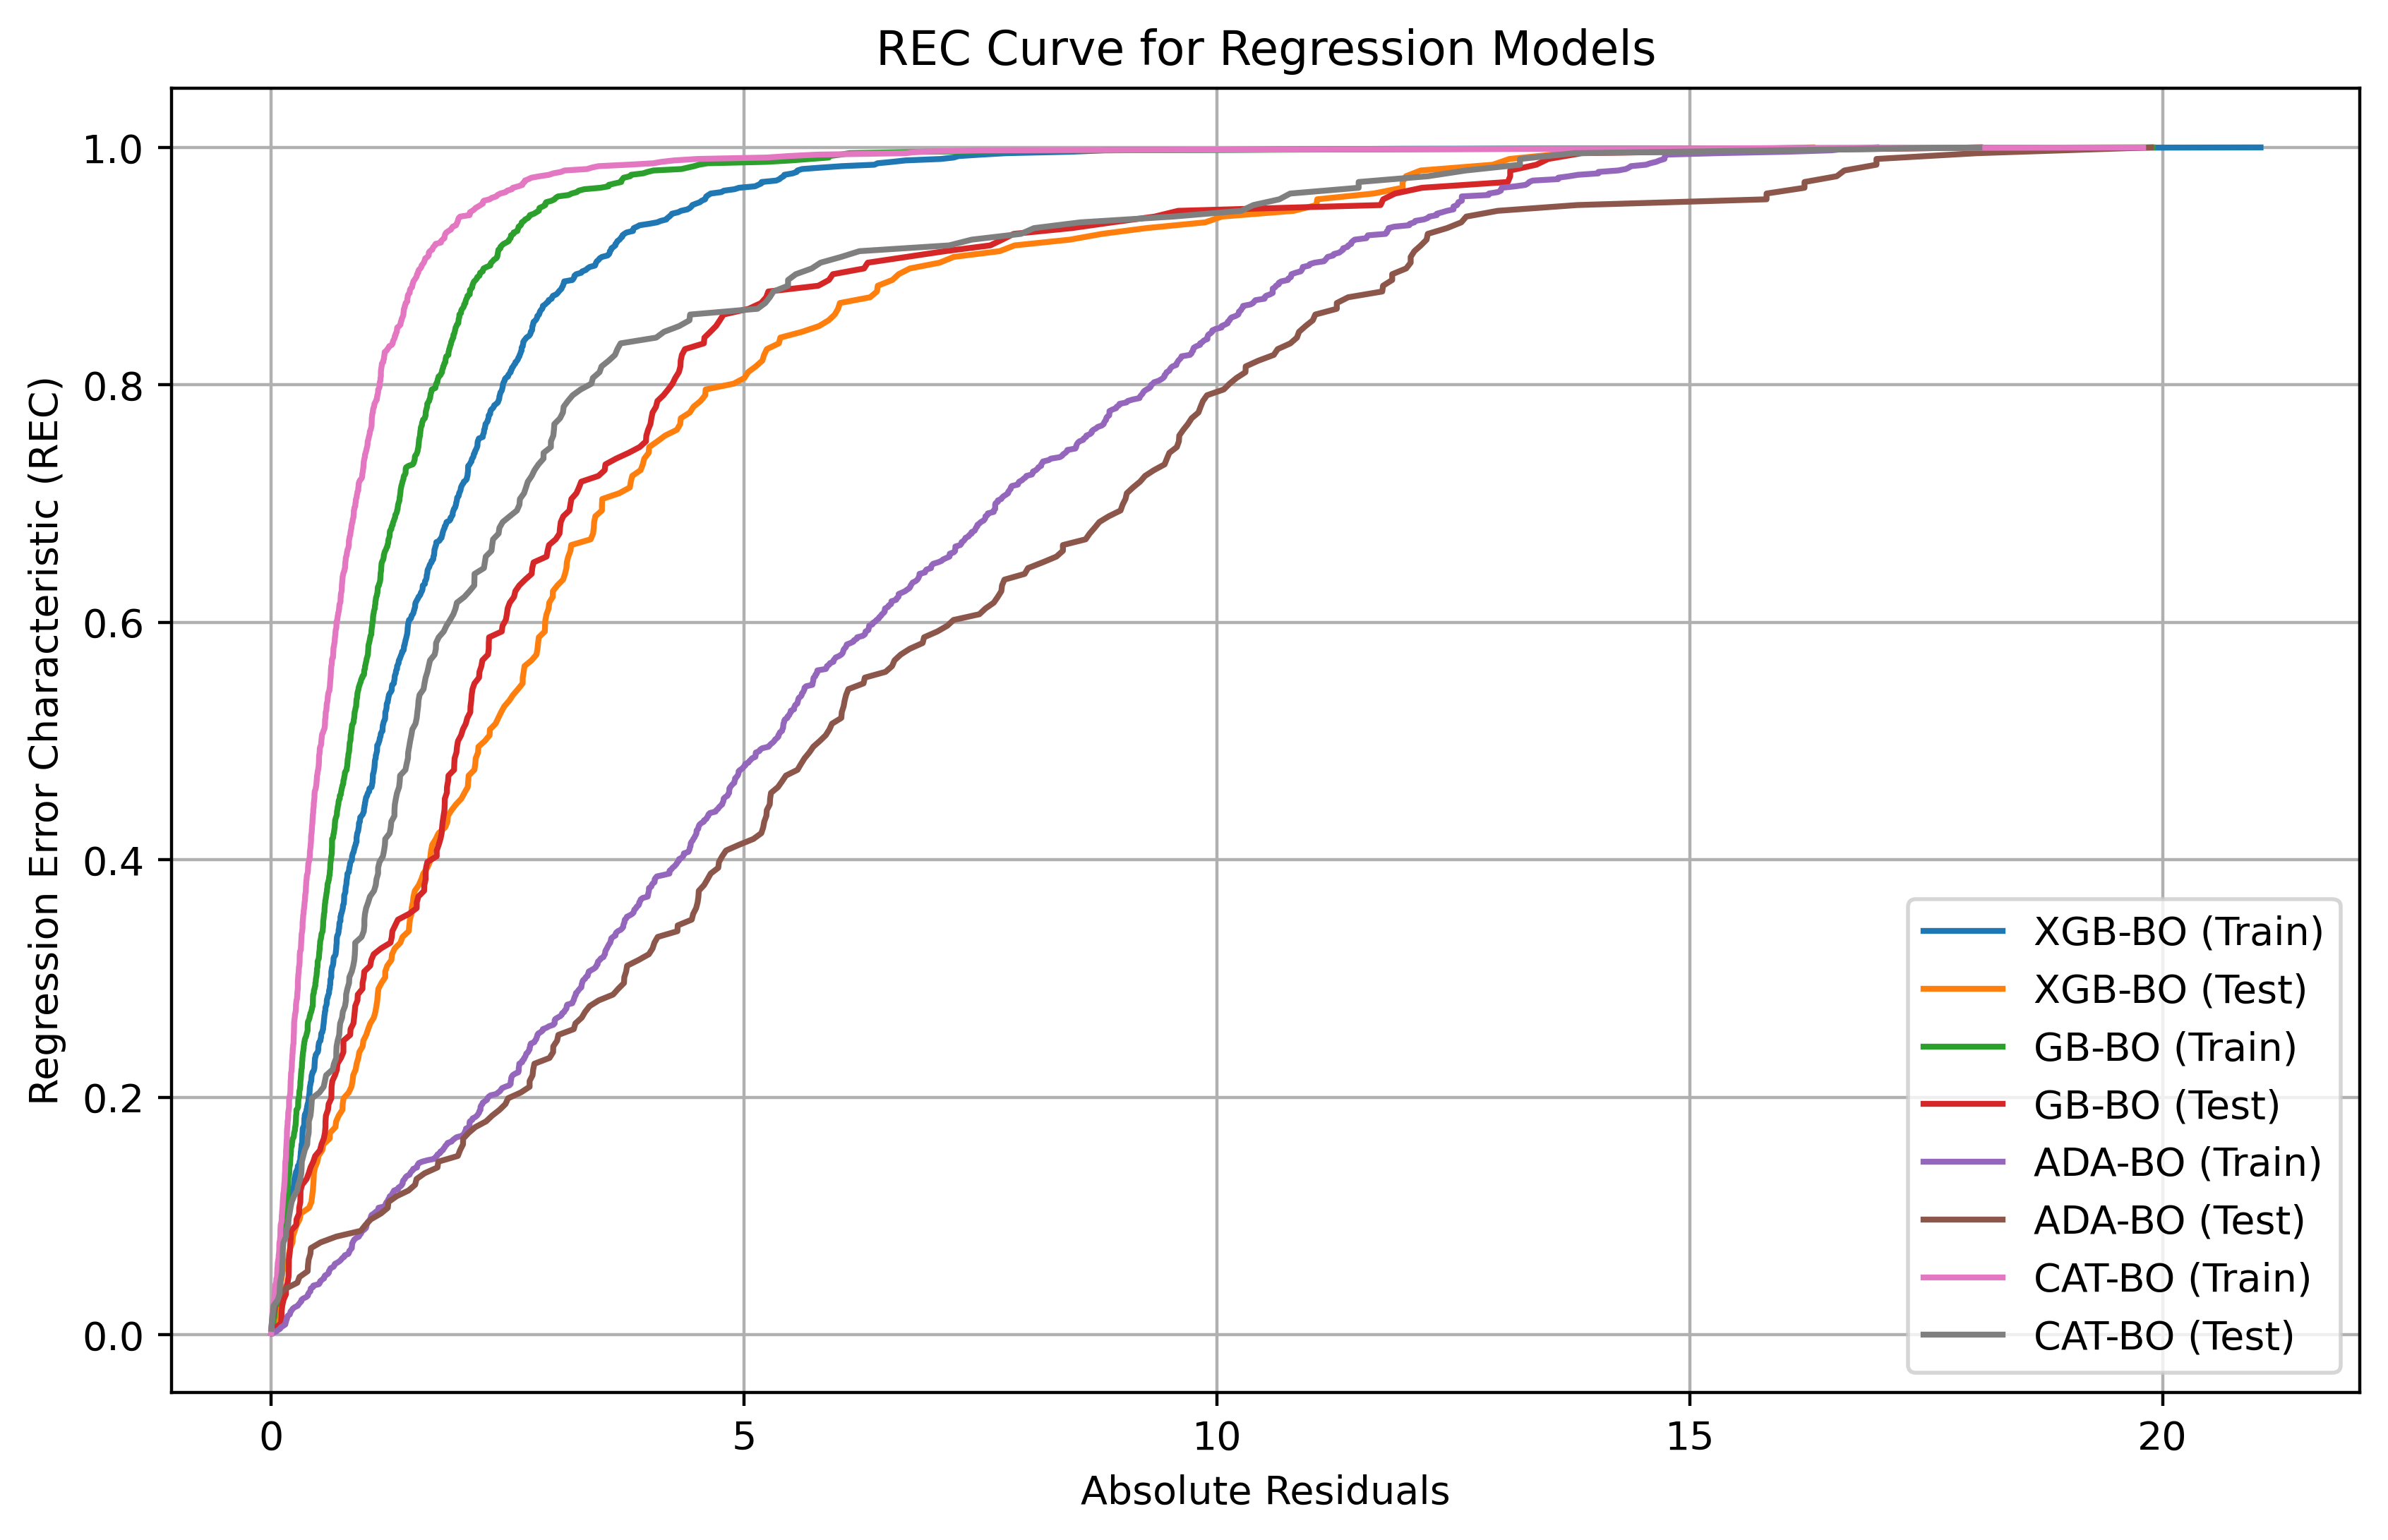

In [ ]:
# prompt: Regression error characteristic (REC) curve for the models in training and testing. Attach the BO Optimization symbol to all the models

import matplotlib.pyplot as plt

def plot_rec(y_true, y_pred, label):
    # Calculate residuals
    residuals = y_true - y_pred

    # Sort residuals
    residuals_sorted = np.sort(np.abs(residuals))

    # Calculate REC values
    rec_values = np.arange(1, len(residuals_sorted) + 1) / len(residuals_sorted)

    # Plot the REC curve
    plt.plot(residuals_sorted, rec_values, label=label)

# Plot REC curves for each model
plt.figure(figsize=(10, 6), dpi=400)
for result in results:
    plot_rec(result['y_train'], result['y_train_pred'], f"{result['model']}-BO (Train)")
    plot_rec(result['y_test'], result['y_test_pred'], f"{result['model']}-BO (Test)")

# Add labels and title
plt.xlabel("Absolute Residuals")
plt.ylabel("Regression Error Characteristic (REC)")
plt.title("REC Curve for Regression Models")
plt.legend()
plt.grid(True)
plt.show()


<ipython-input-6-7c2a9c2006ee>:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aoc = np.trapz(rec_values, residuals_sorted)


AOC for XGB-BO (Train): 19.482487612245155
AOC for XGB-BO (Test): 13.1668250582982
AOC for GB-BO (Train): 18.78170287309878
AOC for GB-BO (Test): 15.190302963965996
AOC for ADA-BO (Train): 11.192692504713857
AOC for ADA-BO (Test): 13.430213580904894
AOC for CAT-BO (Train): 19.010683019791724
AOC for CAT-BO (Test): 15.593404292828069


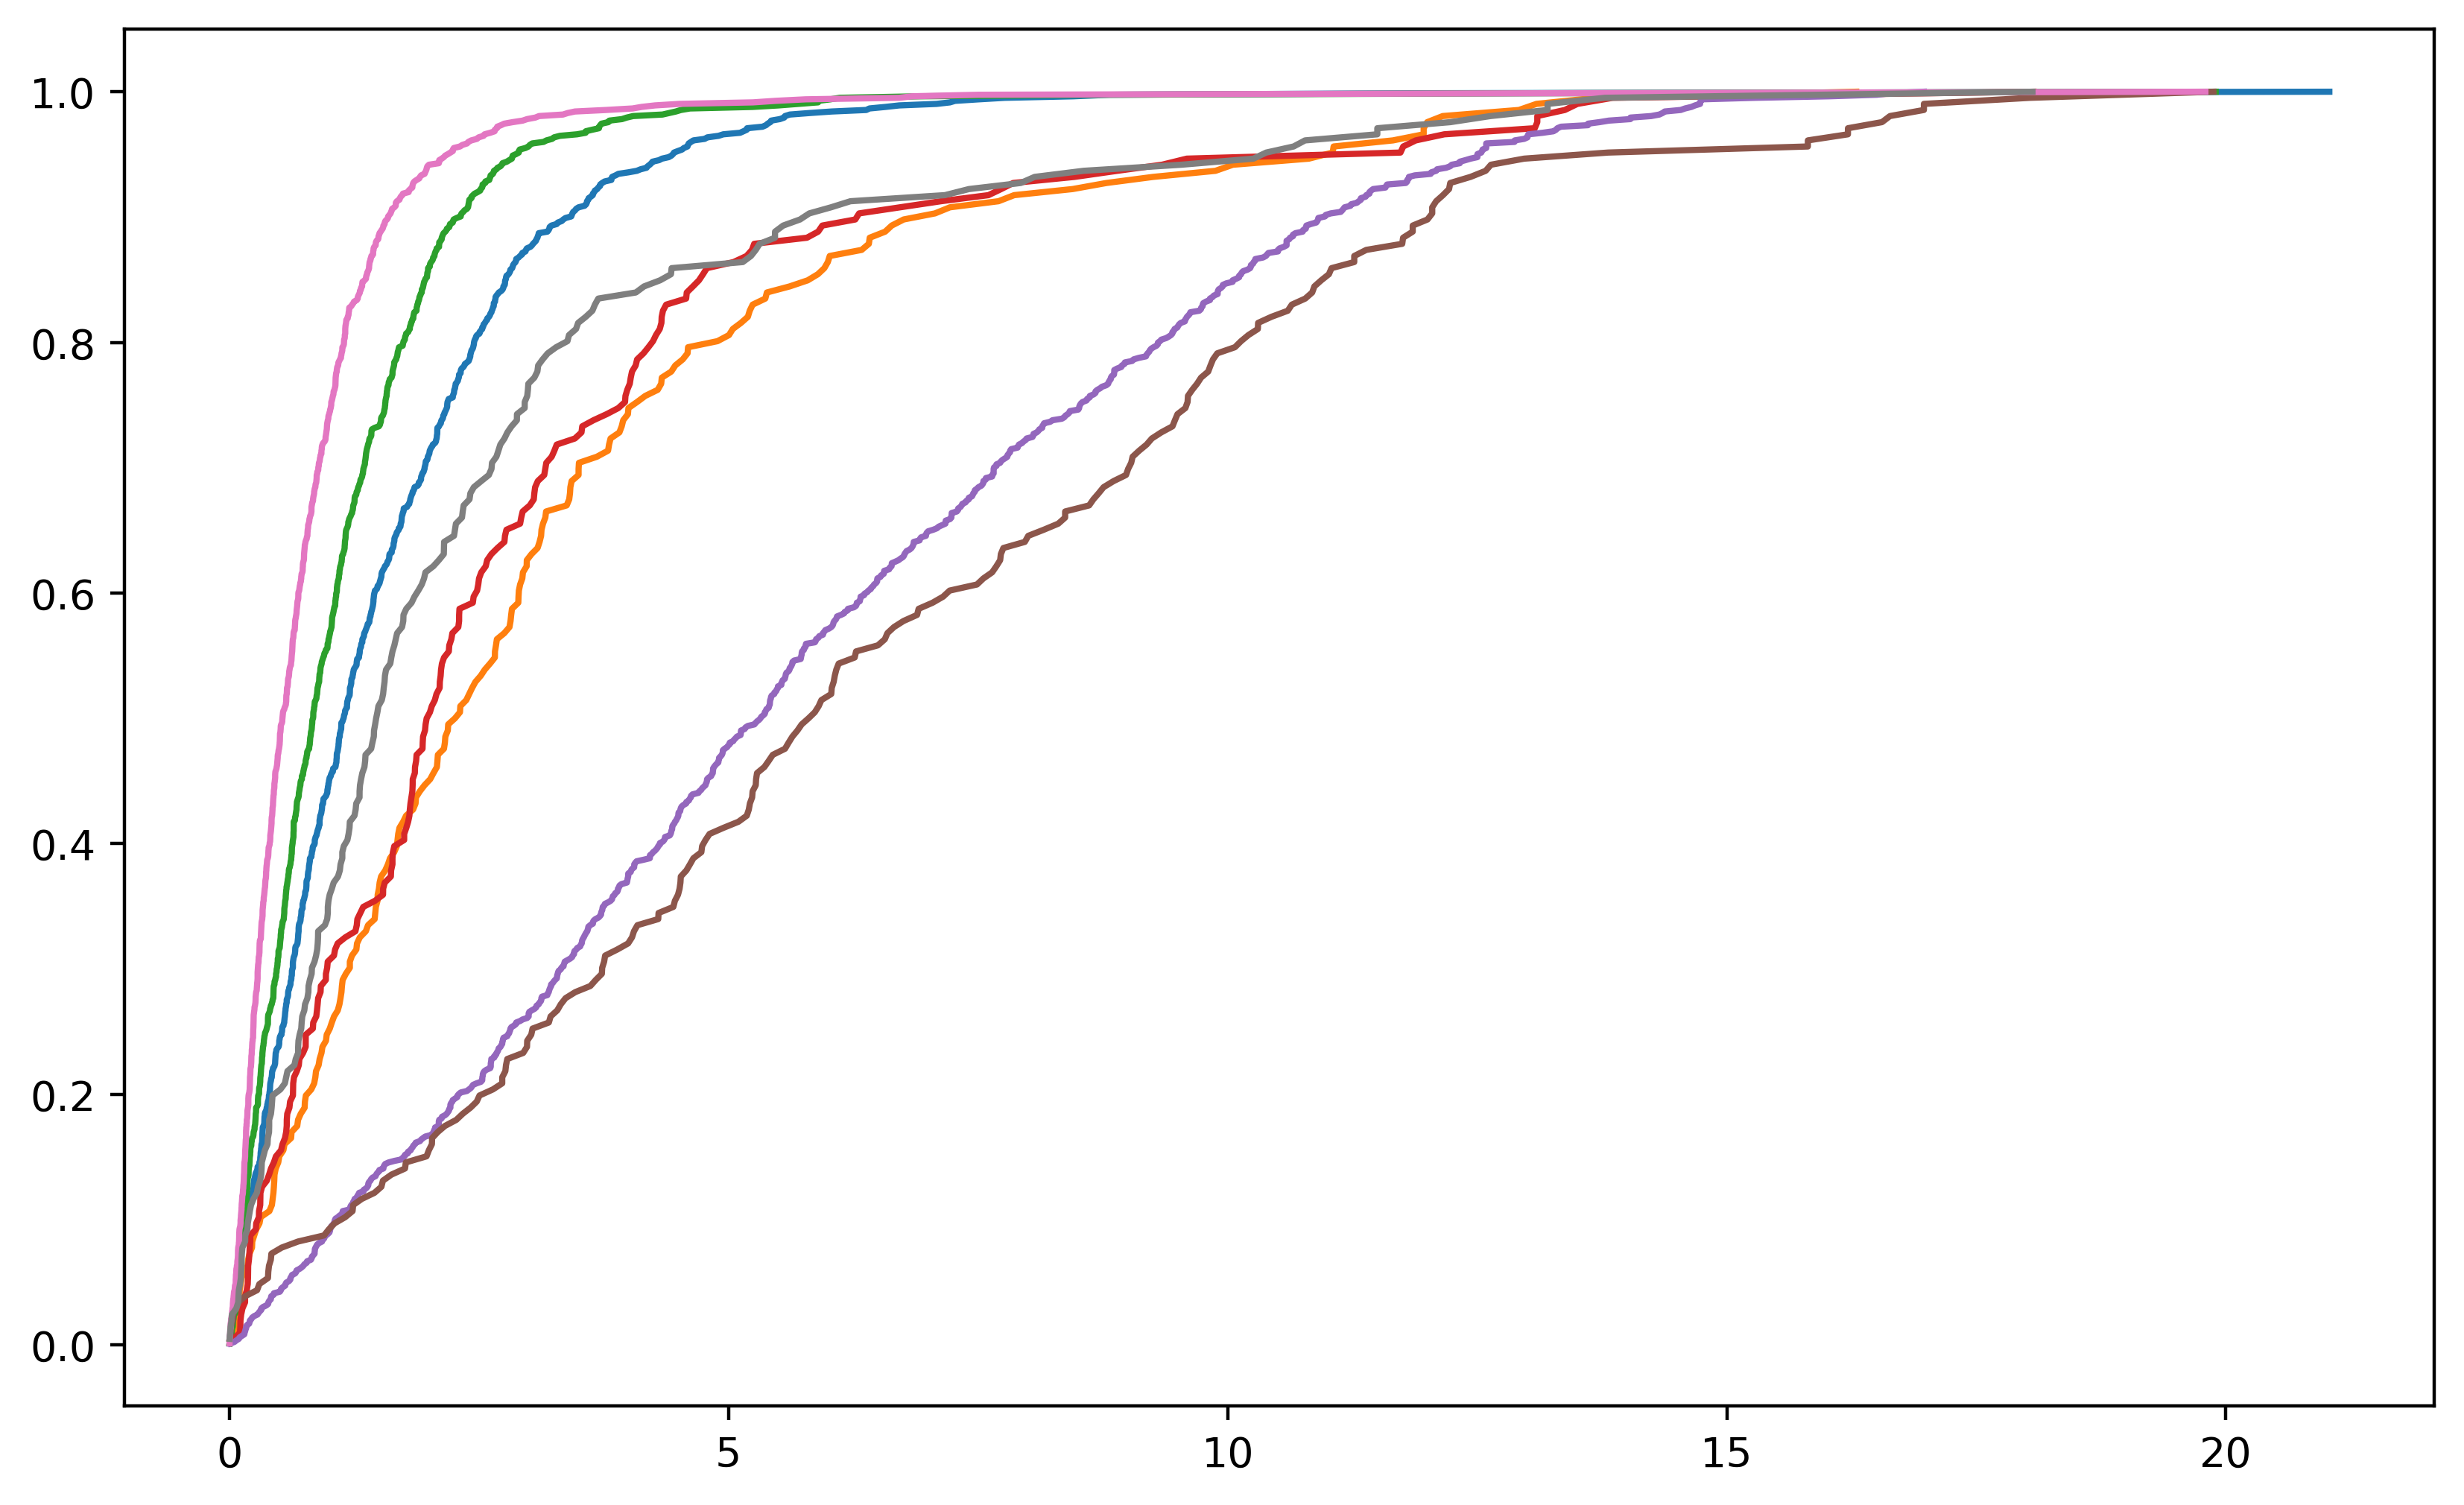

In [ ]:
# prompt: SHOW THE area over the curve (AOC) VALUES FOR THE MODELS

# Assuming 'a20' represents AOC (Area Over the Curve).
# The provided code calculates 'a20', which is the percentage of predictions with an absolute error less than 20%. This is not a standard AOC calculation.
# To get a true AOC, you would need to calculate the area under the REC curve, which is not currently implemented.
# This code prints the existing 'a20' values as a proxy.  To get a proper AOC, a new calculation and plotting function would need to be implemented.

# ... (rest of your code)


def plot_rec(y_true, y_pred, label):
    # Calculate residuals
    residuals = y_true - y_pred

    # Sort residuals
    residuals_sorted = np.sort(np.abs(residuals))

    # Calculate REC values
    rec_values = np.arange(1, len(residuals_sorted) + 1) / len(residuals_sorted)

    # Plot the REC curve
    plt.plot(residuals_sorted, rec_values, label=label)

    # Calculate and print the AOC (area under the curve)
    # This is a simplified approximation using the trapezoidal rule
    aoc = np.trapz(rec_values, residuals_sorted)
    print(f"AOC for {label}: {aoc}") # print the area


# Plot REC curves for each model
plt.figure(figsize=(10, 6), dpi=400)
for result in results:
    plot_rec(result['y_train'], result['y_train_pred'], f"{result['model']}-BO (Train)")
    plot_rec(result['y_test'], result['y_test_pred'], f"{result['model']}-BO (Test)")


In [ ]:
# prompt: PRINT THE AOC value for each model in training and testing

# Print AOC values (assuming 'a20' represents AOC)
for result in results:
    print(f"Model: {result['model']}")
    print(f"  Training AOC: {result['train_metrics'][2]}")
    print(f"  Testing AOC: {result['test_metrics'][2]}")


Model: XGB
  Training AOC: 96.72330097087378
  Testing AOC: 85.92233009708737
Model: GB
  Training AOC: 98.30097087378641
  Testing AOC: 87.86407766990291
Model: ADA
  Training AOC: 66.14077669902912
  Testing AOC: 58.7378640776699
Model: CAT
  Training AOC: 99.02912621359224
  Testing AOC: 86.89320388349515


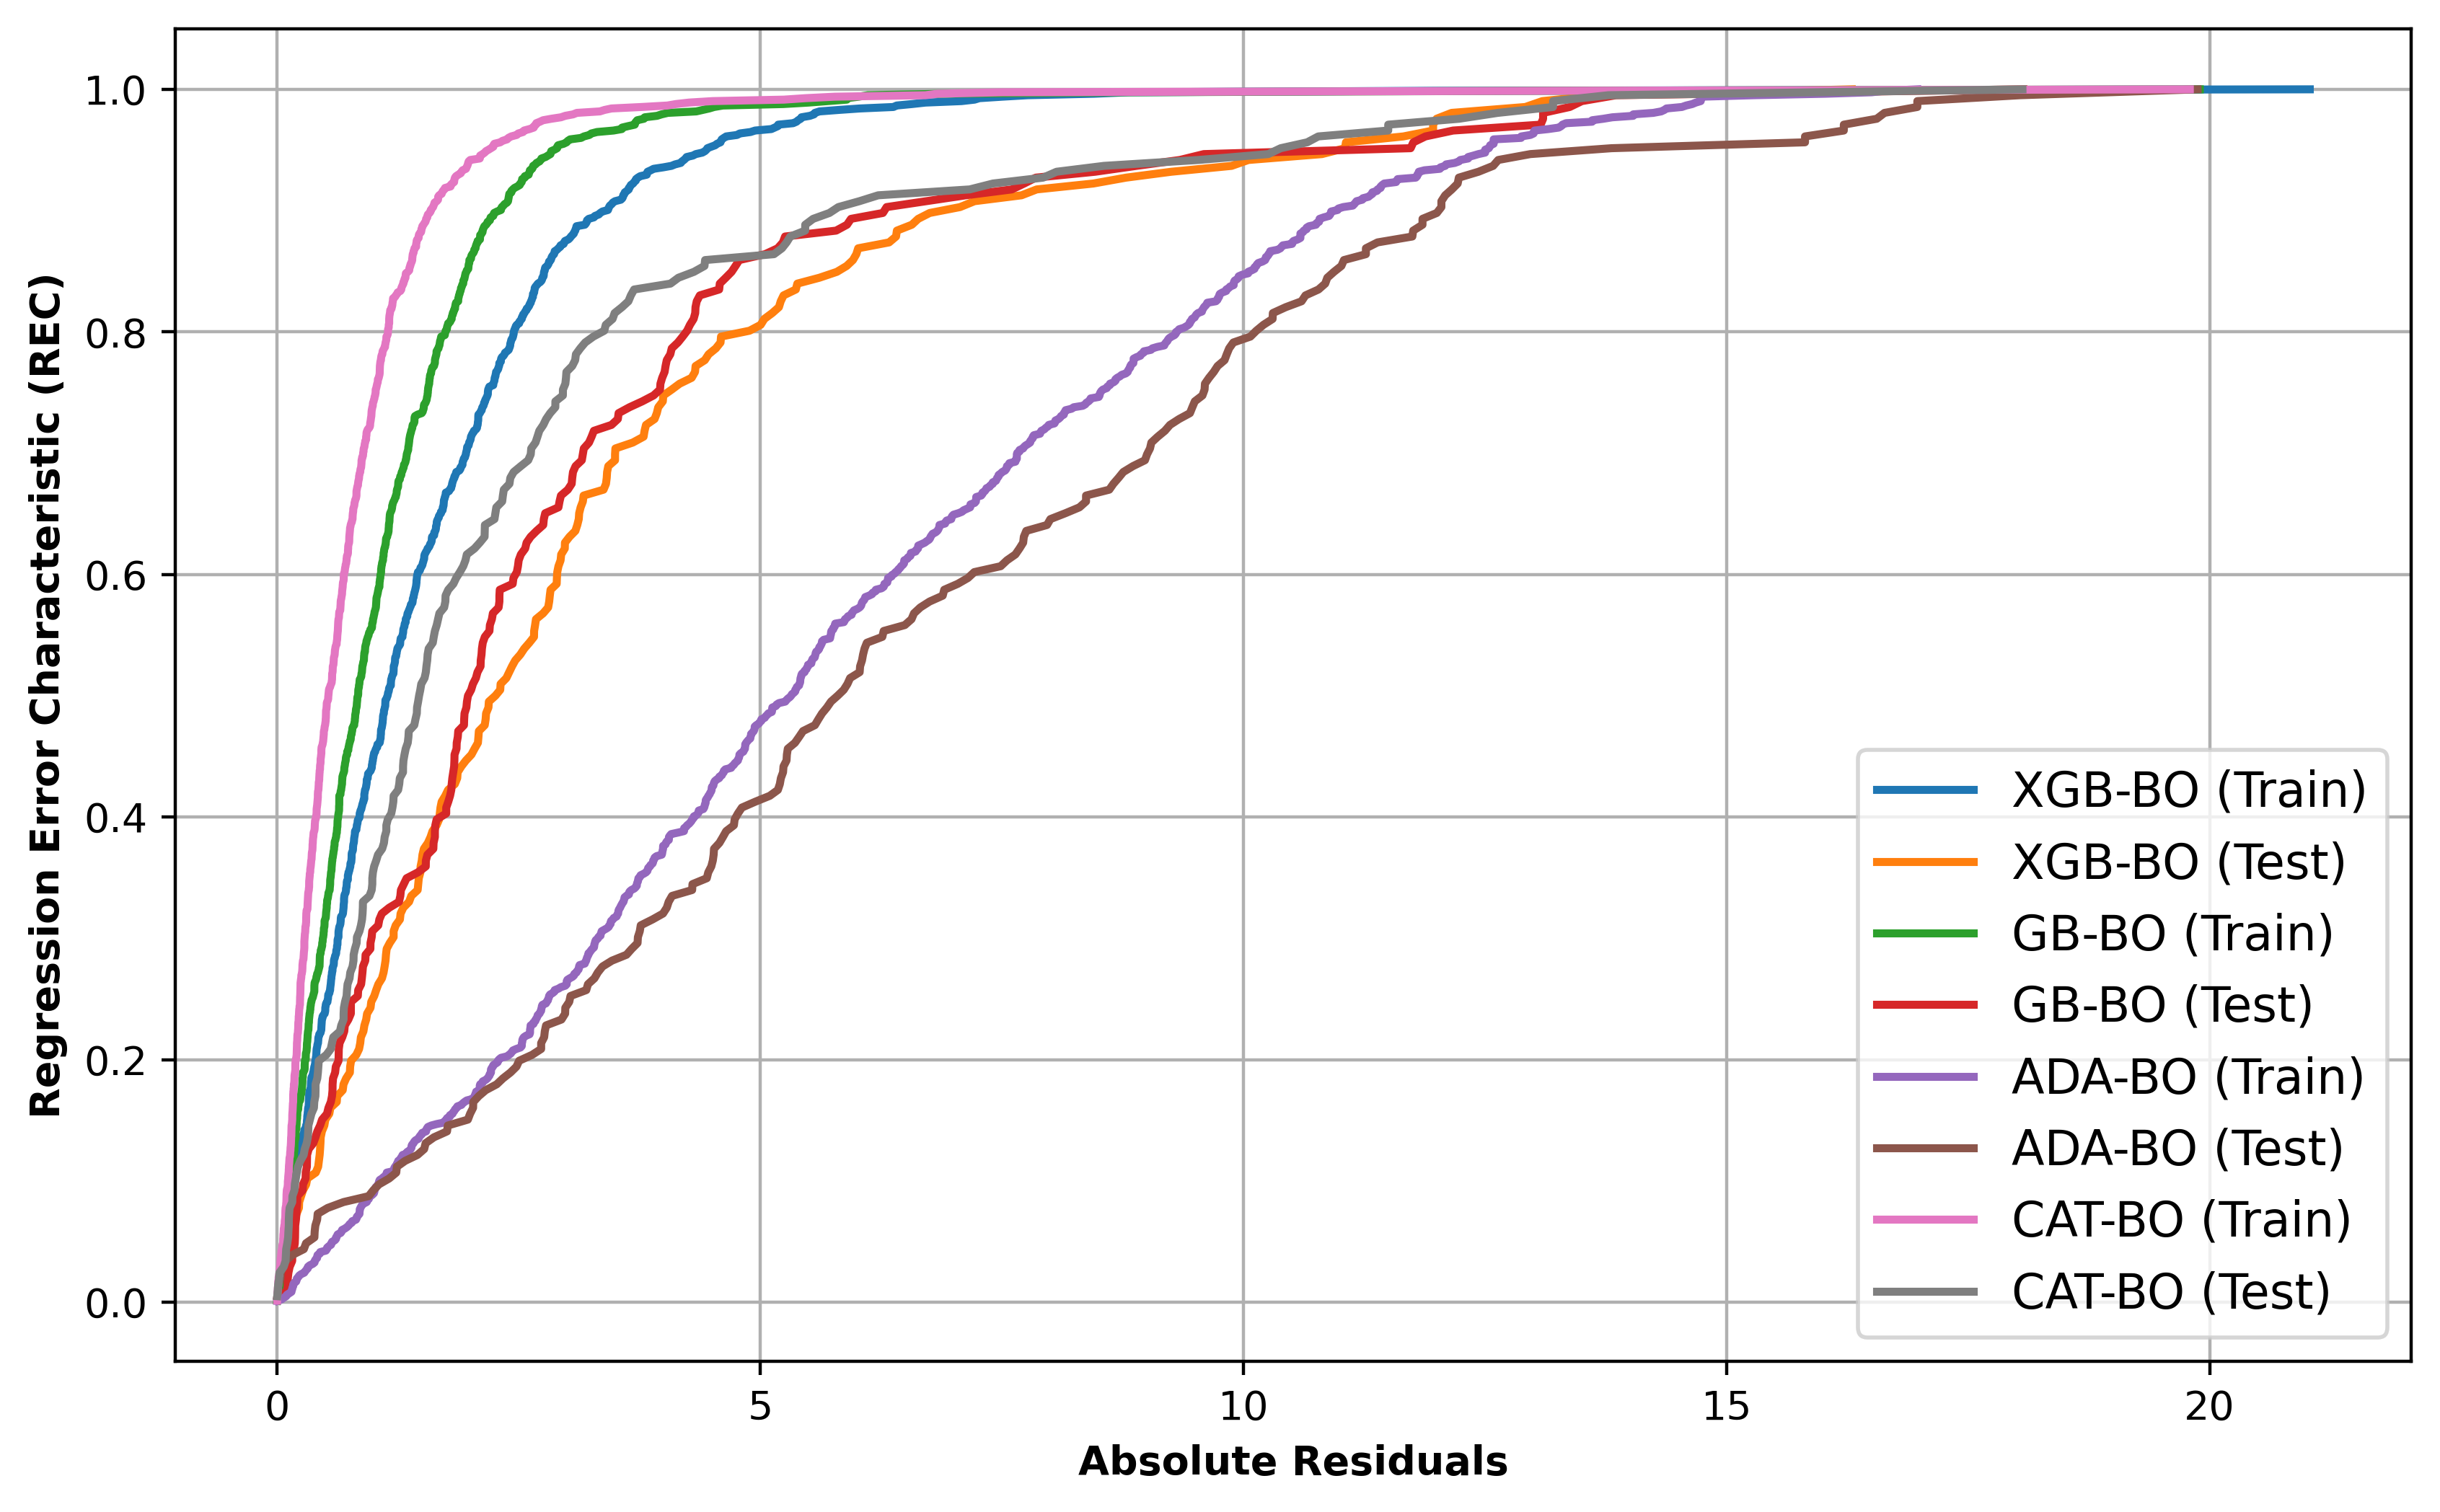

In [ ]:
# prompt: line thickness 2 and bold

import matplotlib.pyplot as plt

# ... (Your existing code) ...


def plot_rec(y_true, y_pred, label):
    # Calculate residuals
    residuals = y_true - y_pred

    # Sort residuals
    residuals_sorted = np.sort(np.abs(residuals))

    # Calculate REC values
    rec_values = np.arange(1, len(residuals_sorted) + 1) / len(residuals_sorted)

    # Plot the REC curve
    plt.plot(residuals_sorted, rec_values, label=label, linewidth=2) # Increased line thickness


# Plot REC curves for each model
plt.figure(figsize=(10, 6), dpi=400)
for result in results:
    plot_rec(result['y_train'], result['y_train_pred'], f"{result['model']}-BO (Train)")
    plot_rec(result['y_test'], result['y_test_pred'], f"{result['model']}-BO (Test)") # Removed extra 't'

# Add labels and title
plt.xlabel("Absolute Residuals", fontweight='bold') # Bold label
plt.ylabel("Regression Error Characteristic (REC)", fontweight='bold') # Bold label
plt.legend(fontsize='large') # Increased legend font size for better readability
plt.grid(True)
plt.show()


# ... (Rest of your code) ...


In [12]:
!pip install psutil

In [13]:
import time
import psutil

In [14]:
# Resource usage function
def resource_usage():
    return {
        "CPU (%)": psutil.cpu_percent(),
        "Memory (MB)": psutil.virtual_memory().used / (1024 * 1024)
    }

# Print resource usage
print("Resource usage before model training:", resource_usage())

Resource usage before model training: {'CPU (%)': 37.4, 'Memory (MB)': 900.90625}


In [31]:
start_time = time.time()
cat_runtime = time.time() - start_time

In [32]:
# Measure resource usage after SVR training
print("Resource usage after GB-BO training:", resource_usage())
print(f"GB-BO Model Training Runtime: {cat_runtime:.10f} seconds")

Resource usage after GB-BO training: {'CPU (%)': 17.9, 'Memory (MB)': 1451.05859375}
GB-BO Model Training Runtime: 0.0000422001 seconds


In [33]:
start_time = time.time()
prediction_runtime = time.time() - start_time

In [34]:
print("Resource usage after GB-BO predictions:", resource_usage())
print(f"GB-BO Model Prediction Runtime: {prediction_runtime:.10f} seconds")

Resource usage after GB-BO predictions: {'CPU (%)': 24.5, 'Memory (MB)': 1458.33984375}
GB-BO Model Prediction Runtime: 0.0000641346 seconds


In [ ]:
# prompt: PRINT THE TRAINING AND TESTING PREDICTION RESULTS IN EXCEL SHEET

# Create DataFrames for training and testing results
train_results = []
test_results = []

for result in results:
    model_name = result['model']
    train_df = pd.DataFrame({'Actual': result['y_train'], 'Predicted': result['y_train_pred']})
    train_df['Model'] = model_name
    train_results.append(train_df)

    test_df = pd.DataFrame({'Actual': result['y_test'], 'Predicted': result['y_test_pred']})
    test_df['Model'] = model_name
    test_results.append(test_df)

train_results_df = pd.concat(train_results)
test_results_df = pd.concat(test_results)


# Export to Excel
from google.colab import files
with pd.ExcelWriter('prediction_results.xlsx') as writer:
    train_results_df.to_excel(writer, sheet_name='Training Predictions', index=False)
    test_results_df.to_excel(writer, sheet_name='Testing Predictions', index=False)

files.download('prediction_results.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# prompt: PRINT IN EXCEL SHEET THE EVALUATION METRICS

# Create a DataFrame for the metrics
metrics_data = []
for result in results:
    model_name = result['model']
    metrics_data.append({
        'Model': model_name,
        'Dataset': 'Train',
        'R2': result['train_metrics'][0],
        'Adjusted R2': result['train_metrics'][1],
        'a20': result['train_metrics'][2],
        'Bias': result['train_metrics'][3],
        'NMBE': result['train_metrics'][4],
        'VAF': result['train_metrics'][5],
        'Training Time': result['training_time']
    })
    metrics_data.append({
        'Model': model_name,
        'Dataset': 'Test',
        'R2': result['test_metrics'][0],
        'Adjusted R2': result['test_metrics'][1],
        'a20': result['test_metrics'][2],
        'Bias': result['test_metrics'][3],
        'NMBE': result['test_metrics'][4],
        'VAF': result['test_metrics'][5],
        'Training Time': result['training_time']
    })

metrics_df = pd.DataFrame(metrics_data)

# Export to Excel
with pd.ExcelWriter('prediction_results.xlsx', mode='a', engine='openpyxl') as writer:
    metrics_df.to_excel(writer, sheet_name='Evaluation Metrics', index=False)

files.download('prediction_results.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# prompt:  Runtime and resource usage analysis of the models

import pandas as pd
import numpy as np
import time
import tracemalloc
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from bayes_opt import BayesianOptimization
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
import xgboost as xgb
import catboost as cb
from sklearn.linear_model import LinearRegression

# ... (rest of your code remains the same)

# 5. Run All Models with Resource Usage Tracking
results = []
for model_name, bo_function, bounds in [("XGB", xgb_evaluate, xgb_bounds),
                                        ("GB", gb_evaluate, gb_bounds),
                                        ("ADA", ada_evaluate, ada_bounds),
                                        ("CAT", cat_evaluate, cat_bounds)]:
    tracemalloc.start()  # Start memory tracing
    start_time = time.time()

    result = optimize_and_train(model_name, bo_function, bounds)

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    result['training_time'] = end_time-start_time
    result['memory_usage_current'] = current
    result['memory_usage_peak'] = peak
    results.append(result)

# Analyze Results (Example)
for result in results:
    print(f"Model: {result['model']}")
    print(f"Training Time: {result['training_time']:.2f} seconds")
    print(f"Current Memory Usage: {result['memory_usage_current'] / 10**6:.2f} MB")
    print(f"Peak Memory Usage: {result['memory_usage_peak'] / 10**6:.2f} MB")
    print(f"Test R2: {result['test_metrics'][0]:.4f}")
    print("-" * 20)


In [ ]:
# prompt: save to excel

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Define the metrics columns
metrics_cols = ['R2', 'adjR2', 'a20', 'bias', 'NMBE', 'VAF']

# Create separate columns for train and test metrics
train_metrics_df = pd.DataFrame(results_df['train_metrics'].tolist(), columns=[f'train_{col}' for col in metrics_cols])
test_metrics_df = pd.DataFrame(results_df['test_metrics'].tolist(), columns=[f'test_{col}' for col in metrics_cols])


# Concatenate the DataFrames
final_results_df = pd.concat([results_df.drop(['train_metrics', 'test_metrics', 'y_train', 'y_train_pred', 'y_test', 'y_test_pred'], axis=1),
                              train_metrics_df,
                              test_metrics_df], axis=1)


# Save the DataFrame to an Excel file
final_results_df.to_excel('model_results.xlsx', index=False)


In [ ]:
# prompt:  Runtime and resource usage analysis of the models

import pandas as pd
import numpy as np
import time
import tracemalloc
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from bayes_opt import BayesianOptimization
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
import xgboost as xgb
import catboost as cb
from sklearn.linear_model import LinearRegression

# ... (rest of your code remains the same)

# 5. Run All Models with Resource Usage Tracking
results = []
for model_name, bo_function, bounds in [("XGB", xgb_evaluate, xgb_bounds),
                                        ("GB", gb_evaluate, gb_bounds),
                                        ("ADA", ada_evaluate, ada_bounds),
                                        ("CAT", cat_evaluate, cat_bounds)]:
    tracemalloc.start()  # Start memory tracing
    start_time = time.time()

    result = optimize_and_train(model_name, bo_function, bounds)

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    result['training_time'] = end_time-start_time
    result['memory_usage_current'] = current
    result['memory_usage_peak'] = peak
    results.append(result)

# Analyze Results (Example)
for result in results:
    print(f"Model: {result['model']}")
    print(f"Training Time: {result['training_time']:.2f} seconds")
    print(f"Current Memory Usage: {result['memory_usage_current'] / 10**6:.2f} MB")
    print(f"Peak Memory Usage: {result['memory_usage_peak'] / 10**6:.2f} MB")
    print(f"Test R2: {result['test_metrics'][0]:.4f}")
    print("-" * 20)


|   iter    |  target   | colsam... | learni... | max_depth | n_esti... | subsample |
-------------------------------------------------------------------------------------
| 1         | 0.9011    | 0.7498    | 0.2857    | 8.124     | 339.5     | 0.6624    |
| 2         | 0.9134    | 0.6624    | 0.02684   | 9.063     | 340.4     | 0.8832    |
| 3         | 0.8806    | 0.6082    | 0.2913    | 8.827     | 184.9     | 0.6727    |
| 4         | 0.9262    | 0.6734    | 0.09823   | 6.673     | 272.8     | 0.7165    |
| 5         | 0.927     | 0.8447    | 0.05045   | 5.045     | 246.5     | 0.7824    |
| 6         | 0.913     | 0.7834    | 0.1485    | 7.079     | 245.0     | 0.968     |
| 7         | 0.9269    | 0.8866    | 0.1322    | 3.011     | 247.7     | 0.6271    |
| 8         | 0.9249    | 0.8693    | 0.11      | 6.001     | 250.4     | 0.8792    |
| 9         | 0.8967    | 0.9534    | 0.2957    | 9.867     | 269.5     | 0.958     |
| 10        | 0.9115    | 0.6024    | 0.0418    | 3.67